In [25]:
import numpy as np
import math
from dataclasses import dataclass
from typing import List, Tuple, Optional
import heapq

###############################################
# Problem Definition (Same as original)
###############################################
Y_LO = -1
Y_HI = 1
X_MAX = math.sqrt(0.5)

@dataclass
class Node:
    """Branch-and-bound tree node"""
    id: int
    y_lb: float
    y_ub: float
    LB: float = -math.inf
    UB: float = math.inf
    
    def __lt__(self, other):
        # For priority queue (min heap based on LB)
        return self.LB < other.LB


###############################################
# Scenario Subproblems (Original formulation)
###############################################

def solve_scenario1_lagrangean(pi, y_lb, y_ub):
    """
    Scenario 1 Lagrangean subproblem:
        min -x1 + pi*y1
        s.t. y1 = ±x1^2, 0 ≤ x1 ≤ X_MAX, y1 ∈ [y_lb, y_ub]
    """
    xs = np.linspace(0.0, min(X_MAX, math.sqrt(abs(y_ub))), 2001)
    
    best_val = None
    best_y = None
    best_x = None
    
    for x1 in xs:
        for y_candidate in [x1**2, -x1**2]:
            if y_lb <= y_candidate <= y_ub:
                obj = -x1 + pi * y_candidate
                if best_val is None or obj < best_val:
                    best_val = obj
                    best_y = y_candidate
                    best_x = x1
    
    return {
        "z_star": best_val,
        "y_star": best_y,
        "x_star": best_x
    }


def solve_scenario2_lagrangean(pi, y_lb, y_ub):
    """
    Scenario 2 Lagrangean subproblem:
        min x2 - pi*y2
        s.t. |y2| ≤ x2^2, 0 ≤ x2 ≤ X_MAX, y2 ∈ [y_lb, y_ub]
    """
    xs = np.linspace(0.0, X_MAX, 2001)
    
    best_val = None
    best_y = None
    best_x = None
    
    for x2 in xs:
        y_lo_feasible = max(-x2**2, y_lb)
        y_hi_feasible = min(x2**2, y_ub)
        
        if y_lo_feasible > y_hi_feasible:
            continue
        
        # Optimal y2 for fixed x2
        if pi >= 0:
            y2 = y_hi_feasible
        else:
            y2 = y_lo_feasible
        
        obj = x2 - pi * y2
        if best_val is None or obj < best_val:
            best_val = obj
            best_y = y2
            best_x = x2
    
    return {
        "z_star": best_val,
        "y_star": best_y,
        "x_star": best_x
    }


###############################################
# Benders Subproblems (with convex relaxation)
###############################################

def solve_scenario1_benders(y_shared, cuts, y_lb, y_ub):
    """
    Scenario 1 Benders subproblem (convexified):
        min -x1
        s.t. y_shared = ±x1^2 (relaxed with McCormick + cuts)
             0 ≤ x1 ≤ X_MAX
    """
    xs = np.linspace(0.0, X_MAX, 1001)
    
    best_val = None
    best_x = None
    feasible = False
    
    for x1 in xs:
        # Check if y_shared can be satisfied
        y_candidates = [x1**2, -x1**2]
        
        for y_cand in y_candidates:
            # Check feasibility with tolerance
            if abs(y_cand - y_shared) < 1e-3 and y_lb <= y_cand <= y_ub:
                # Check additional cuts
                cuts_satisfied = True
                for cut in cuts:
                    if cut['alpha_x'] * x1 < cut['beta'] - 1e-6:
                        cuts_satisfied = False
                        break
                
                if cuts_satisfied:
                    obj = -x1
                    if best_val is None or obj < best_val:
                        best_val = obj
                        best_x = x1
                        feasible = True
    
    if not feasible:
        # Return infeasible indicator
        return {"z_star": 1e6, "x_star": None, "feasible": False}
    
    return {
        "z_star": best_val,
        "x_star": best_x,
        "feasible": True
    }


def solve_scenario2_benders(y_shared, cuts, y_lb, y_ub):
    """
    Scenario 2 Benders subproblem (convexified):
        min x2
        s.t. |y_shared| ≤ x2^2
             0 ≤ x2 ≤ X_MAX
    """
    xs = np.linspace(0.0, X_MAX, 1001)
    
    best_val = None
    best_x = None
    feasible = False
    
    for x2 in xs:
        # Check feasibility: |y_shared| ≤ x2^2
        if abs(y_shared) <= x2**2 + 1e-6 and y_lb <= y_shared <= y_ub:
            # Check additional cuts
            cuts_satisfied = True
            for cut in cuts:
                if cut['alpha_x'] * x2 < cut['beta'] - 1e-6:
                    cuts_satisfied = False
                    break
            
            if cuts_satisfied:
                obj = x2
                if best_val is None or obj < best_val:
                    best_val = obj
                    best_x = x2
                    feasible = True
    
    if not feasible:
        return {"z_star": 1e6, "x_star": None, "feasible": False}
    
    return {
        "z_star": best_val,
        "x_star": best_x,
        "feasible": True
    }


###############################################
# Benders Master Problem
###############################################

def solve_benders_master(lagrangean_cuts, benders_cuts, y_lb, y_ub):
    """
    Benders Master Problem:
        min eta1 + eta2
        s.t. eta1 ≥ z1_l - pi_l * y  (Lagrangean cuts)
             eta2 ≥ z2_l + pi_l * y
             eta1 ≥ z1_k + lambda1_k * (y - y_k)  (Benders cuts)
             eta2 ≥ z2_k + lambda2_k * (y - y_k)
             y ∈ [y_lb, y_ub]
    """
    y_grid = np.linspace(y_lb, y_ub, 2001)
    
    best_obj = None
    best_y = None
    
    for y in y_grid:
        # Evaluate Lagrangean cuts for scenario 1
        eta1 = -math.inf
        for cut in lagrangean_cuts['scenario1']:
            eta1 = max(eta1, cut['z'] - cut['pi'] * y)
        
        # Evaluate Lagrangean cuts for scenario 2
        eta2 = -math.inf
        for cut in lagrangean_cuts['scenario2']:
            eta2 = max(eta2, cut['z'] + cut['pi'] * y)
        
        # Evaluate Benders cuts for scenario 1
        for cut in benders_cuts['scenario1']:
            eta1 = max(eta1, cut['z'] + cut['lambda'] * (y - cut['y']))
        
        # Evaluate Benders cuts for scenario 2
        for cut in benders_cuts['scenario2']:
            eta2 = max(eta2, cut['z'] + cut['lambda'] * (y - cut['y']))
        
        total = eta1 + eta2
        if best_obj is None or total < best_obj:
            best_obj = total
            best_y = y
    
    return best_obj, best_y


###############################################
# Upper Bound Heuristic
###############################################

def compute_upper_bound(y_shared):
    """
    Fix y and solve each scenario to get feasible solution
    """
    # Scenario 1: find x1 such that y_shared = ±x1^2
    val1 = abs(y_shared)
    if val1 > X_MAX**2 + 1e-6:
        return math.inf
    
    x1 = math.sqrt(val1)
    if x1 > X_MAX + 1e-6:
        return math.inf
    cost1 = -x1
    
    # Scenario 2: find x2 such that |y_shared| ≤ x2^2
    val2 = abs(y_shared)
    if val2 > X_MAX**2 + 1e-6:
        return math.inf
    
    x2 = math.sqrt(val2)
    if x2 > X_MAX + 1e-6:
        return math.inf
    cost2 = x2
    
    return cost1 + cost2


###############################################
# Generate Simple Cutting Planes
###############################################

def generate_cut_scenario1(y_shared, x_star):
    """
    Generate a simple linearization cut for scenario 1
    For y = x^2 constraint, add tangent cut: y ≥ 2*x_star*x - x_star^2
    """
    if x_star is None:
        return None
    
    # Tangent approximation
    return {
        'alpha_x': 2 * x_star,
        'beta': x_star**2
    }


def generate_cut_scenario2(y_shared, x_star):
    """
    Generate a simple linearization cut for scenario 2
    """
    if x_star is None:
        return None
    
    return {
        'alpha_x': 2 * abs(x_star),
        'beta': x_star**2
    }


###############################################
# Algorithm 1: Solve Single Node
###############################################

def solve_node(node: Node, max_lag_iter=5, max_benders_iter=10):
    """
    Algorithm 1: Decomposition algorithm to solve a single node
    """
    y_lb, y_ub = node.y_lb, node.y_ub
    
    # Initialize
    lagrangean_cuts = {'scenario1': [], 'scenario2': []}
    benders_cuts = {'scenario1': [], 'scenario2': []}
    scenario1_cuts = []
    scenario2_cuts = []
    
    pi = 0.0  # Lagrangean multiplier
    theta = 0.5  # Step size parameter
    alpha_cap = 0.3
    
    UB = math.inf
    LB = -math.inf
    
    # Phase 1: Lagrangean iterations
    print(f"  [Node {node.id}] Phase 1: Lagrangean Iterations")
    for l in range(max_lag_iter):
        # Solve Lagrangean subproblems
        s1 = solve_scenario1_lagrangean(pi, y_lb, y_ub)
        s2 = solve_scenario2_lagrangean(pi, y_lb, y_ub)
        
        y1_star = s1['y_star']
        y2_star = s2['y_star']
        z1_star = s1['z_star']
        z2_star = s2['z_star']
        
        # Lagrangean lower bound
        LB_lag = z1_star + z2_star
        LB = max(LB, LB_lag)
        
        # Add Lagrangean cuts
        lagrangean_cuts['scenario1'].append({'z': z1_star, 'pi': pi})
        lagrangean_cuts['scenario2'].append({'z': z2_star, 'pi': pi})
        
        # Update multiplier (subgradient method)
        g = y1_star - y2_star
        gap = max(UB - LB, 0)
        alpha = min(theta * gap / (g**2 + 1e-12), alpha_cap)
        pi = pi + alpha * g
        theta *= 0.9  # Decay
        
        print(f"    Lag iter {l+1}: LB={LB:.4f}, y1={y1_star:.3f}, y2={y2_star:.3f}, pi={pi:.3f}")
    
    # Phase 2: Benders iterations
    print(f"  [Node {node.id}] Phase 2: Benders Iterations")
    for k in range(max_benders_iter):
        # Solve Benders master
        LB_master, y_shared = solve_benders_master(
            lagrangean_cuts, benders_cuts, y_lb, y_ub
        )
        LB = max(LB, LB_master)
        
        # Solve Benders subproblems
        s1_benders = solve_scenario1_benders(y_shared, scenario1_cuts, y_lb, y_ub)
        s2_benders = solve_scenario2_benders(y_shared, scenario2_cuts, y_lb, y_ub)
        
        if not s1_benders['feasible'] or not s2_benders['feasible']:
            print(f"    Benders iter {k+1}: Infeasible subproblem")
            # Add feasibility cut (simplified)
            continue
        
        # Generate and add cutting planes
        new_cut1 = generate_cut_scenario1(y_shared, s1_benders['x_star'])
        new_cut2 = generate_cut_scenario2(y_shared, s2_benders['x_star'])
        
        if new_cut1:
            scenario1_cuts.append(new_cut1)
        if new_cut2:
            scenario2_cuts.append(new_cut2)
        
        # Generate Benders cuts (using subgradient)
        z1_k = s1_benders['z_star']
        z2_k = s2_benders['z_star']
        
        # Approximate subgradient (numerical differentiation)
        eps = 1e-4
        if y_shared + eps <= y_ub:
            s1_plus = solve_scenario1_benders(y_shared + eps, scenario1_cuts, y_lb, y_ub)
            lambda1 = (s1_plus['z_star'] - z1_k) / eps if s1_plus['feasible'] else 0
        else:
            lambda1 = 0
        
        if y_shared + eps <= y_ub:
            s2_plus = solve_scenario2_benders(y_shared + eps, scenario2_cuts, y_lb, y_ub)
            lambda2 = (s2_plus['z_star'] - z2_k) / eps if s2_plus['feasible'] else 0
        else:
            lambda2 = 0
        
        benders_cuts['scenario1'].append({
            'z': z1_k, 'lambda': lambda1, 'y': y_shared
        })
        benders_cuts['scenario2'].append({
            'z': z2_k, 'lambda': lambda2, 'y': y_shared
        })
        
        # Compute upper bound
        UB_k = compute_upper_bound(y_shared)
        UB = min(UB, UB_k)
        
        gap = UB - LB
        print(f"    Benders iter {k+1}: LB={LB:.4f}, UB={UB:.4f}, gap={gap:.4f}, y={y_shared:.3f}")
        
        # Check convergence
        if gap < 1e-3:
            print(f"    Converged!")
            break
    
    node.LB = LB
    node.UB = UB
    return node


###############################################
# Algorithm 2: Branch-and-Bound
###############################################

def branch_and_bound(max_nodes=50, tolerance=1e-3):
    """
    Algorithm 2: Branch-and-Bound framework
    """
    # Initialize root node
    root = Node(id=0, y_lb=Y_LO, y_ub=Y_HI)
    
    # Priority queue of active nodes (min-heap based on LB)
    active_nodes = [root]
    node_counter = 1
    
    # Global bounds
    global_UB = math.inf
    global_LB = -math.inf
    
    nodes_solved = 0
    
    print("="*60)
    print("Starting Branch-and-Bound Algorithm")
    print("="*60)
    
    while active_nodes and nodes_solved < max_nodes:
        # Select node with smallest LB
        current_node = heapq.heappop(active_nodes)
        
        print(f"\n[B&B] Processing Node {current_node.id} "
              f"[{current_node.y_lb:.3f}, {current_node.y_ub:.3f}]")
        
        # Solve current node
        current_node = solve_node(current_node)
        nodes_solved += 1
        
        # Update global bounds
        global_LB = min(n.LB for n in active_nodes) if active_nodes else current_node.LB
        global_LB = max(global_LB, current_node.LB)
        global_UB = min(global_UB, current_node.UB)
        
        gap = global_UB - global_LB
        print(f"[B&B] Global: LB={global_LB:.4f}, UB={global_UB:.4f}, gap={gap:.4f}")
        
        # Check global convergence
        if gap < tolerance:
            print(f"\n{'='*60}")
            print(f"OPTIMAL SOLUTION FOUND!")
            print(f"Objective: {global_UB:.6f}")
            print(f"Gap: {gap:.6f}")
            print(f"Nodes solved: {nodes_solved}")
            print(f"{'='*60}")
            return global_UB, global_LB
        
        # Fathoming
        if current_node.LB >= global_UB - tolerance:
            print(f"  [Fathomed by bound]")
            continue
        
        if current_node.UB - current_node.LB < tolerance:
            print(f"  [Fathomed by optimality]")
            continue
        
        # Branching (bisection on y)
        y_mid = (current_node.y_lb + current_node.y_ub) / 2
        
        # Create child nodes
        left_child = Node(
            id=node_counter,
            y_lb=current_node.y_lb,
            y_ub=y_mid,
            LB=current_node.LB  # Inherit parent's LB
        )
        node_counter += 1
        
        right_child = Node(
            id=node_counter,
            y_lb=y_mid,
            y_ub=current_node.y_ub,
            LB=current_node.LB
        )
        node_counter += 1
        
        heapq.heappush(active_nodes, left_child)
        heapq.heappush(active_nodes, right_child)
        
        print(f"  [Branched into Nodes {left_child.id} and {right_child.id}]")
    
    print(f"\n{'='*60}")
    print(f"Branch-and-Bound Terminated")
    print(f"Best solution: {global_UB:.6f}")
    print(f"Best bound: {global_LB:.6f}")
    print(f"Gap: {global_UB - global_LB:.6f}")
    print(f"Nodes solved: {nodes_solved}")
    print(f"{'='*60}")
    
    return global_UB, global_LB


###############################################
# Main Execution
###############################################

if __name__ == "__main__":
    # Run the full algorithm
    UB, LB = branch_and_bound(max_nodes=30, tolerance=1e-8)
    
    print(f"\n\nFINAL RESULT:")
    print(f"  Upper Bound: {UB:.6f}")
    print(f"  Lower Bound: {LB:.6f}")
    print(f"  Gap: {UB - LB:.6f}")

Starting Branch-and-Bound Algorithm

[B&B] Processing Node 0 [-1.000, 1.000]
  [Node 0] Phase 1: Lagrangean Iterations
    Lag iter 1: LB=-0.7071, y1=0.500, y2=0.000, pi=0.150
    Lag iter 2: LB=-0.7071, y1=-0.500, y2=0.000, pi=0.000
    Lag iter 3: LB=-0.7071, y1=0.500, y2=0.000, pi=0.150
    Lag iter 4: LB=-0.7071, y1=-0.500, y2=0.000, pi=0.000
    Lag iter 5: LB=-0.7071, y1=0.500, y2=0.000, pi=0.150
  [Node 0] Phase 2: Benders Iterations
    Benders iter 1: LB=-0.7071, UB=0.0000, gap=0.7071, y=-0.500
    Benders iter 2: LB=0.0000, UB=0.0000, gap=0.0000, y=-0.500
    Converged!
[B&B] Global: LB=0.0000, UB=0.0000, gap=0.0000

OPTIMAL SOLUTION FOUND!
Objective: 0.000000
Gap: 0.000000
Nodes solved: 1


FINAL RESULT:
  Upper Bound: 0.000000
  Lower Bound: 0.000000
  Gap: 0.000000


In [22]:
import numpy as np
import math

###############################################
# Problem setup
#
# - Two scenarios
# - Each has local y (y1, y2), and local x decisions
# - We allow y in [-0.5, 0.5]
# - x is bounded so that feasibility is respected:
#       scenario 1: y1 = ± x1^2
#       scenario 2: |y2| <= x2^2
#   which effectively implies x <= sqrt(0.5)
#
# We'll denote:
#   pi : Lagrange multiplier for the "nonanticipativity"
#        constraint y1 = y2.
###############################################

Y_LO = -0.5
Y_HI =  0.5
X_MAX = math.sqrt(0.5)  # ~0.70710678118

def solve_scenario1_given_pi(pi):
    """
    Scenario 1 subproblem:
        minimize   -x1 + pi*y1
        s.t.       y1 = + x1^2   or   y1 = - x1^2
                   0 <= x1 <= X_MAX
                   y1 in [Y_LO, Y_HI]
    We pick the better sign (because we're minimizing).
    We'll just evaluate both signs at the best x1 and choose the smaller objective.
    """

    # Because objective is like -x1 ± pi*(x1^2),
    # it's 1D continuous. We'll just brute-force scan x1 in [0, X_MAX].
    xs = np.linspace(0.0, X_MAX, 2001)

    best_val = None
    best_y = None
    best_x = None

    for x1 in xs:
        y_pos =  x1**2   # y1 = + x1^2
        y_neg = -x1**2   # y1 = - x1^2

        # Check bounds
        if Y_LO <= y_pos <= Y_HI:
            obj_pos = -x1 + pi*y_pos
            if (best_val is None) or (obj_pos < best_val):
                best_val = obj_pos
                best_y   = y_pos
                best_x   = x1

        if Y_LO <= y_neg <= Y_HI:
            obj_neg = -x1 + pi*y_neg
            if (best_val is None) or (obj_neg < best_val):
                best_val = obj_neg
                best_y   = y_neg
                best_x   = x1

    return {
        "z_star": best_val,     # scenario 1's Lagrangian min value
        "y_star": best_y,       # y1^*
        "x_star": best_x,
    }

def solve_scenario2_given_pi(pi):
    """
    Scenario 2 subproblem:
        minimize   x2 - pi*y2
        s.t.       |y2| <= x2^2
                   0 <= x2 <= X_MAX
                   y2 in [Y_LO, Y_HI]

    For fixed x2, the best y2 to MINIMIZE x2 - pi*y2 is:
        - if pi>0, we want y2 as large as possible (y2 = min(x2^2, Y_HI))
        - if pi<0, we want y2 as negative as possible (y2 = max(-x2^2, Y_LO))
    We'll brute-force x2 in [0, X_MAX].
    """

    xs = np.linspace(0.0, X_MAX, 2001)

    best_val = None
    best_y = None
    best_x = None

    for x2 in xs:
        # feasible y2 satisfies |y2| <= x2^2, and y2 in [Y_LO, Y_HI].
        y_can_hi = min(x2**2, Y_HI)
        y_can_lo = max(-x2**2, Y_LO)

        if pi >= 0:
            y2 = y_can_hi
        else:
            y2 = y_can_lo

        # objective = x2 - pi*y2
        obj = x2 - pi*y2
        if (best_val is None) or (obj < best_val):
            best_val = obj
            best_y   = y2
            best_x   = x2

    return {
        "z_star": best_val,     # scenario 2's Lagrangian min value
        "y_star": best_y,       # y2^*
        "x_star": best_x,
    }


###############################################
# Master cuts
#
# After solving each scenario at current pi, we build Lagrangean cuts:
#   For scenario 1:
#       eta1 >= z1_star - pi * y_shared
#   For scenario 2:
#       eta2 >= z2_star + pi * y_shared
#
# Master problem:
#   minimize eta1 + eta2
#   s.t. all accumulated cuts
#   and y_shared in [Y_LO, Y_HI]
#
# Because each cut is linear in y_shared,
# we can solve master cheaply by scanning y_shared grid and taking
#   LB_master(y) = min over eta1,eta2 of eta1+eta2
#                = max over i cuts1_i(...)  + max over j cuts2_j(...)
#
# where cuts1_i(y) = z1_i - pi_i * y
#       cuts2_j(y) = z2_j + pi_j * y
#
# That is: for a given y_shared, we evaluate all cuts for scenario1,
# pick the tightest (largest RHS), that's eta1_min(y);
# same for scenario2, then sum.
###############################################

def master_solve(cuts, y_grid=None):
    """
    cuts is a list of dicts:
        {"scen":1, "z":z1_star, "pi":pi_at_that_time}
        {"scen":2, "z":z2_star, "pi":pi_at_that_time}
    We'll separate them into scen1_cuts, scen2_cuts,
    then scan candidate y_shared ∈ [Y_LO,Y_HI] to find:
        LB_master = min_y [ max_i (z1_i - pi_i*y) + max_j (z2_j + pi_j*y) ]
    We also return the y_shared achieving that LB.

    This is literally solving the linear master with all Lagrangean cuts.
    """
    scen1_cuts = [(c["z"], c["pi"]) for c in cuts if c["scen"]==1]
    scen2_cuts = [(c["z"], c["pi"]) for c in cuts if c["scen"]==2]

    if y_grid is None:
        y_grid = np.linspace(Y_LO, Y_HI, 2001)

    best_obj = None
    best_y   = None

    for y in y_grid:
        # eta1 >= z_i - pi_i * y  for all i in scen1_cuts
        # => eta1_min(y) = max_i [z_i - pi_i * y]
        eta1_min_y = max(z - pi*y for (z,pi) in scen1_cuts)

        # eta2 >= z_j + pi_j * y  for all j in scen2_cuts
        # => eta2_min(y) = max_j [z_j + pi_j * y]
        eta2_min_y = max(z + pi*y for (z,pi) in scen2_cuts)

        total = eta1_min_y + eta2_min_y
        if (best_obj is None) or (total < best_obj):
            best_obj = total
            best_y   = y

    return best_obj, best_y  # LB_master, y_shared


###############################################
# Feasible UB from a shared y
#
# Given y_shared, we enforce y1=y2=y_shared and solve each
# original scenario objective WITHOUT pi terms:
#
#   Scenario1 true cost = min_{x1} (-x1) s.t. y_shared = ± x1^2
#   Scenario2 true cost = min_{x2} ( x2) s.t. |y_shared| <= x2^2
#
# If y_shared is infeasible under these constraints, UB=+inf.
###############################################

def feasible_cost_scen1(y_shared):
    # We require y_shared = ± x1^2
    # So if |y_shared| not achievable as a square within X_MAX^2, infeasible.
    val_abs = abs(y_shared)
    if val_abs > X_MAX**2 + 1e-12:
        return math.inf

    # feasible x1 must satisfy x1^2 = val_abs
    x1 = math.sqrt(val_abs)
    if x1 > X_MAX + 1e-12:
        return math.inf

    # objective true cost = -x1
    # (the sign of y doesn't matter for objective in true cost)
    return -x1

def feasible_cost_scen2(y_shared):
    # Need |y_shared| <= x2^2 with 0<=x2<=X_MAX
    val_abs = abs(y_shared)
    if val_abs > X_MAX**2 + 1e-12:
        return math.inf

    # The best cost in scenario2 true objective is min x2
    # subject to x2^2 >= |y_shared|.
    # So x2 must be at least sqrt(|y_shared|).
    x2 = math.sqrt(val_abs)
    if x2 > X_MAX + 1e-12:
        return math.inf

    return x2  # cost = x2


def compute_feasible_UB(y_shared):
    c1 = feasible_cost_scen1(y_shared)
    c2 = feasible_cost_scen2(y_shared)
    total = c1 + c2
    return total


###############################################
# Multiplier update (subgradient / Polyak style)
#
# pi_{k+1} = pi_k + alpha_k * g_k
# where g_k = y1_star - y2_star  (violation of consensus)
# alpha_k ~ theta * (UB - LB) / ||g||^2, clipped by alpha_cap
###############################################

def update_multiplier(pi, y1_star, y2_star, UB, LB, theta, alpha_cap):
    g = y1_star - y2_star
    gap = UB - LB
    if gap < 0:
        gap = 0.0
    denom = g*g + 1e-12
    alpha = theta * gap / denom
    if alpha > alpha_cap:
        alpha = alpha_cap
    new_pi = pi + alpha * g
    return new_pi, alpha, g, gap


###############################################
# Main loop (manual Lagrangean + cuts + master)
###############################################

def run_manual(rounds=3, pi0=0.8, theta0=0.5, alpha_cap=0.3):
    pi = pi0
    theta = theta0
    cuts = []

    bestUB = math.inf
    last_gap = None

    history = []

    for k in range(1, rounds+1):
        # 1. solve each scenario at current pi
        s1 = solve_scenario1_given_pi(pi)
        s2 = solve_scenario2_given_pi(pi)

        y1_star = s1["y_star"]
        y2_star = s2["y_star"]
        z1_star = s1["z_star"]
        z2_star = s2["z_star"]

        # 2. raw Lagrangean LB
        LB_lag = z1_star + z2_star

        # 3. add cuts of this iteration
        #   scen1 cut: eta1 >= z1_star - pi*y_shared
        cuts.append({"scen":1, "z":z1_star, "pi":pi})
        #   scen2 cut: eta2 >= z2_star + pi*y_shared
        cuts.append({"scen":2, "z":z2_star, "pi":pi})

        # 4. solve master using all cuts so far
        LB_master, y_shared = master_solve(cuts)

        LB_effective = max(LB_lag, LB_master)

        # 5. feasible UB from that y_shared
        UB_val = compute_feasible_UB(y_shared)
        if UB_val < bestUB:
            bestUB = UB_val

        gap_now = bestUB - LB_effective

        # 6. multiplier update
        new_pi, alpha_used, g, polyak_gap = update_multiplier(
            pi, y1_star, y2_star, bestUB, LB_effective, theta, alpha_cap
        )

        # aggressive theta decay if no improvement in gap
        if last_gap is not None:
            if gap_now > last_gap - 1e-4:
                theta *= 0.5
        last_gap = gap_now

        # log
        info = {
            "iter": k,
            "pi_before": pi,
            "pi_after": new_pi,
            "theta": theta,
            "alpha": alpha_used,
            "y1_star": y1_star,
            "y2_star": y2_star,
            "y_shared": y_shared,
            "LB_lag": LB_lag,
            "LB_master": LB_master,
            "LB_effective": LB_effective,
            "UB_best": bestUB,
            "gap": gap_now,
            "g": g,
            "polyak_gap": polyak_gap,
        }
        history.append(info)

        # prepare next round
        pi = new_pi

    return history


if __name__ == "__main__":
    hist = run_manual(rounds=9, pi0=0.8, theta0=0.5, alpha_cap=0.3)

    for h in hist:
        print(f"iter {h['iter']:02d} | "
              f"y1={h['y1_star']:+.3f}, y2={h['y2_star']:+.3f}, "
              f"y_shared={h['y_shared']:+.3f} | "
              f"LB={h['LB_effective']:+.6f} | "
              f"UB={h['UB_best']:+.6f} | "
              f"gap={h['gap']:.3f} | "
              f"pi_before={h['pi_before']:+.3f} -> pi_after={h['pi_after']:+.3f} "
              f"(alpha={h['alpha']:.3f}, theta={h['theta']:.3f})")


iter 01 | y1=-0.500, y2=+0.000, y_shared=+0.188 | LB=-1.106353 | UB=+0.000000 | gap=1.106 | pi_before=+0.800 -> pi_after=+0.650 (alpha=0.300, theta=0.500)
iter 02 | y1=-0.500, y2=+0.000, y_shared=-0.009 | LB=-1.031503 | UB=+0.000000 | gap=1.032 | pi_before=+0.650 -> pi_after=+0.500 (alpha=0.300, theta=0.500)
iter 03 | y1=-0.500, y2=+0.000, y_shared=-0.499 | LB=-0.956653 | UB=+0.000000 | gap=0.957 | pi_before=+0.500 -> pi_after=+0.350 (alpha=0.300, theta=0.500)
iter 04 | y1=-0.500, y2=+0.000, y_shared=-0.499 | LB=-0.881803 | UB=+0.000000 | gap=0.882 | pi_before=+0.350 -> pi_after=+0.201 (alpha=0.300, theta=0.500)
iter 05 | y1=-0.500, y2=+0.000, y_shared=-0.499 | LB=-0.806953 | UB=+0.000000 | gap=0.807 | pi_before=+0.201 -> pi_after=+0.051 (alpha=0.300, theta=0.500)
iter 06 | y1=-0.500, y2=+0.000, y_shared=-0.499 | LB=-0.732103 | UB=+0.000000 | gap=0.732 | pi_before=+0.051 -> pi_after=-0.099 (alpha=0.300, theta=0.500)
iter 07 | y1=+0.500, y2=-0.000, y_shared=+0.000 | LB=-0.732103 | UB=+0

In [ ]:
import numpy as np
import math

###############################################
# Problem setup
#
# - Two scenarios
# - Each has local y (y1, y2), and local x decisions
# - We allow y in [-0.5, 0.5]
# - x is bounded so that feasibility is respected:
#       scenario 1: y1 = ± x1^2
#       scenario 2: |y2| <= x2^2
#   which effectively implies x <= sqrt(0.5)
#
# We'll denote:
#   pi : Lagrange multiplier for the "nonanticipativity"
#        constraint y1 = y2.
###############################################

Y_LO = -0.5
Y_HI =  0.5
X_MAX = math.sqrt(0.5)  # ~0.70710678118

def solve_scenario1_given_pi(pi):
    """
    Scenario 1 subproblem:
        minimize   -x1 + pi*y1
        s.t.       y1 = + x1^2   or   y1 = - x1^2
                   0 <= x1 <= X_MAX
                   y1 in [Y_LO, Y_HI]
    We pick the better sign (because we're minimizing).
    We'll just evaluate both signs at the best x1 and choose the smaller objective.
    """

    # Because objective is like -x1 ± pi*(x1^2),
    # it's 1D continuous. We'll just brute-force scan x1 in [0, X_MAX].
    xs = np.linspace(0.0, X_MAX, 2001)

    best_val = None
    best_y = None
    best_x = None

    for x1 in xs:
        y_pos =  x1**2   # y1 = + x1^2
        y_neg = -x1**2   # y1 = - x1^2

        # Check bounds
        if Y_LO <= y_pos <= Y_HI:
            obj_pos = -x1 + pi*y_pos
            if (best_val is None) or (obj_pos < best_val):
                best_val = obj_pos
                best_y   = y_pos
                best_x   = x1

        if Y_LO <= y_neg <= Y_HI:
            obj_neg = -x1 + pi*y_neg
            if (best_val is None) or (obj_neg < best_val):
                best_val = obj_neg
                best_y   = y_neg
                best_x   = x1

    return {
        "z_star": best_val,     # scenario 1's Lagrangian min value
        "y_star": best_y,       # y1^*
        "x_star": best_x,
    }

def solve_scenario2_given_pi(pi):
    """
    Scenario 2 subproblem:
        minimize   x2 - pi*y2
        s.t.       |y2| <= x2^2
                   0 <= x2 <= X_MAX
                   y2 in [Y_LO, Y_HI]

    For fixed x2, the best y2 to MINIMIZE x2 - pi*y2 is:
        - if pi>0, we want y2 as large as possible (y2 = min(x2^2, Y_HI))
        - if pi<0, we want y2 as negative as possible (y2 = max(-x2^2, Y_LO))
    We'll brute-force x2 in [0, X_MAX].
    """

    xs = np.linspace(0.0, X_MAX, 2001)

    best_val = None
    best_y = None
    best_x = None

    for x2 in xs:
        # feasible y2 satisfies |y2| <= x2^2, and y2 in [Y_LO, Y_HI].
        y_can_hi = min(x2**2, Y_HI)
        y_can_lo = max(-x2**2, Y_LO)

        if pi >= 0:
            y2 = y_can_hi
        else:
            y2 = y_can_lo

        # objective = x2 - pi*y2
        obj = x2 - pi*y2
        if (best_val is None) or (obj < best_val):
            best_val = obj
            best_y   = y2
            best_x   = x2

    return {
        "z_star": best_val,     # scenario 2's Lagrangian min value
        "y_star": best_y,       # y2^*
        "x_star": best_x,
    }


###############################################
# Master cuts
#
# After solving each scenario at current pi, we build Lagrangean cuts:
#   For scenario 1:
#       eta1 >= z1_star - pi * y_shared
#   For scenario 2:
#       eta2 >= z2_star + pi * y_shared
#
# Master problem:
#   minimize eta1 + eta2
#   s.t. all accumulated cuts
#   and y_shared in [Y_LO, Y_HI]
#
# Because each cut is linear in y_shared,
# we can solve master cheaply by scanning y_shared grid and taking
#   LB_master(y) = min over eta1,eta2 of eta1+eta2
#                = max over i cuts1_i(...)  + max over j cuts2_j(...)
#
# where cuts1_i(y) = z1_i - pi_i * y
#       cuts2_j(y) = z2_j + pi_j * y
#
# That is: for a given y_shared, we evaluate all cuts for scenario1,
# pick the tightest (largest RHS), that's eta1_min(y);
# same for scenario2, then sum.
###############################################

def master_solve(cuts, y_grid=None):
    """
    cuts is a list of dicts:
        {"scen":1, "z":z1_star, "pi":pi_at_that_time}
        {"scen":2, "z":z2_star, "pi":pi_at_that_time}
    We'll separate them into scen1_cuts, scen2_cuts,
    then scan candidate y_shared ∈ [Y_LO,Y_HI] to find:
        LB_master = min_y [ max_i (z1_i - pi_i*y) + max_j (z2_j + pi_j*y) ]
    We also return the y_shared achieving that LB.

    This is literally solving the linear master with all Lagrangean cuts.
    """
    scen1_cuts = [(c["z"], c["pi"]) for c in cuts if c["scen"]==1]
    scen2_cuts = [(c["z"], c["pi"]) for c in cuts if c["scen"]==2]

    if y_grid is None:
        y_grid = np.linspace(Y_LO, Y_HI, 2001)

    best_obj = None
    best_y   = None

    for y in y_grid:
        # eta1 >= z_i - pi_i * y  for all i in scen1_cuts
        # => eta1_min(y) = max_i [z_i - pi_i * y]
        eta1_min_y = max(z - pi*y for (z,pi) in scen1_cuts)

        # eta2 >= z_j + pi_j * y  for all j in scen2_cuts
        # => eta2_min(y) = max_j [z_j + pi_j * y]
        eta2_min_y = max(z + pi*y for (z,pi) in scen2_cuts)

        total = eta1_min_y + eta2_min_y
        if (best_obj is None) or (total < best_obj):
            best_obj = total
            best_y   = y

    return best_obj, best_y  # LB_master, y_shared


###############################################
# Feasible UB from a shared y
#
# Given y_shared, we enforce y1=y2=y_shared and solve each
# original scenario objective WITHOUT pi terms:
#
#   Scenario1 true cost = min_{x1} (-x1) s.t. y_shared = ± x1^2
#   Scenario2 true cost = min_{x2} ( x2) s.t. |y_shared| <= x2^2
#
# If y_shared is infeasible under these constraints, UB=+inf.
###############################################

def feasible_cost_scen1(y_shared):
    # We require y_shared = ± x1^2
    # So if |y_shared| not achievable as a square within X_MAX^2, infeasible.
    val_abs = abs(y_shared)
    if val_abs > X_MAX**2 + 1e-12:
        return math.inf

    # feasible x1 must satisfy x1^2 = val_abs
    x1 = math.sqrt(val_abs)
    if x1 > X_MAX + 1e-12:
        return math.inf

    # objective true cost = -x1
    # (the sign of y doesn't matter for objective in true cost)
    return -x1

def feasible_cost_scen2(y_shared):
    # Need |y_shared| <= x2^2 with 0<=x2<=X_MAX
    val_abs = abs(y_shared)
    if val_abs > X_MAX**2 + 1e-12:
        return math.inf

    # The best cost in scenario2 true objective is min x2
    # subject to x2^2 >= |y_shared|.
    # So x2 must be at least sqrt(|y_shared|).
    x2 = math.sqrt(val_abs)
    if x2 > X_MAX + 1e-12:
        return math.inf

    return x2  # cost = x2


def compute_feasible_UB(y_shared):
    c1 = feasible_cost_scen1(y_shared)
    c2 = feasible_cost_scen2(y_shared)
    total = c1 + c2
    return total


###############################################
# Multiplier update (subgradient / Polyak style)
#
# pi_{k+1} = pi_k + alpha_k * g_k
# where g_k = y1_star - y2_star  (violation of consensus)
# alpha_k ~ theta * (UB - LB) / ||g||^2, clipped by alpha_cap
###############################################

def update_multiplier(pi, y1_star, y2_star, UB, LB, theta, alpha_cap):
    g = y1_star - y2_star
    gap = UB - LB
    if gap < 0:
        gap = 0.0
    denom = g*g + 1e-12
    alpha = theta * gap / denom
    if alpha > alpha_cap:
        alpha = alpha_cap
    new_pi = pi + alpha * g
    return new_pi, alpha, g, gap


###############################################
# Main loop (manual Lagrangean + cuts + master)
###############################################

def run_manual(rounds=3, pi0=0.8, theta0=0.5, alpha_cap=0.3):
    pi = pi0
    theta = theta0
    cuts = []

    bestUB = math.inf
    last_gap = None

    history = []

    for k in range(1, rounds+1):
        # 1. solve each scenario at current pi
        s1 = solve_scenario1_given_pi(pi)
        s2 = solve_scenario2_given_pi(pi)

        y1_star = s1["y_star"]
        y2_star = s2["y_star"]
        z1_star = s1["z_star"]
        z2_star = s2["z_star"]

        # 2. raw Lagrangean LB
        LB_lag = z1_star + z2_star

        # 3. add cuts of this iteration
        #   scen1 cut: eta1 >= z1_star - pi*y_shared
        cuts.append({"scen":1, "z":z1_star, "pi":pi})
        #   scen2 cut: eta2 >= z2_star + pi*y_shared
        cuts.append({"scen":2, "z":z2_star, "pi":pi})

        # 4. solve master using all cuts so far
        LB_master, y_shared = master_solve(cuts)

        LB_effective = max(LB_lag, LB_master)

        # 5. feasible UB from that y_shared
        UB_val = compute_feasible_UB(y_shared)
        if UB_val < bestUB:
            bestUB = UB_val

        gap_now = bestUB - LB_effective

        # 6. multiplier update
        new_pi, alpha_used, g, polyak_gap = update_multiplier(
            pi, y1_star, y2_star, bestUB, LB_effective, theta, alpha_cap
        )

        # aggressive theta decay if no improvement in gap
        if last_gap is not None:
            if gap_now > last_gap - 1e-4:
                theta *= 0.5
        last_gap = gap_now

        # log
        info = {
            "iter": k,
            "pi_before": pi,
            "pi_after": new_pi,
            "theta": theta,
            "alpha": alpha_used,
            "y1_star": y1_star,
            "y2_star": y2_star,
            "y_shared": y_shared,
            "LB_lag": LB_lag,
            "LB_master": LB_master,
            "LB_effective": LB_effective,
            "UB_best": bestUB,
            "gap": gap_now,
            "g": g,
            "polyak_gap": polyak_gap,
        }
        history.append(info)

        # prepare next round
        pi = new_pi

    return history


if __name__ == "__main__":
    hist = run_manual(rounds=3, pi0=0.8, theta0=0.5, alpha_cap=0.3)

    for h in hist:
        print(f"iter {h['iter']:02d} | "
              f"y1={h['y1_star']:+.3f}, y2={h['y2_star']:+.3f}, "
              f"y_shared={h['y_shared']:+.3f} | "
              f"LB={h['LB_effective']:+.6f} | "
              f"UB={h['UB_best']:+.6f} | "
              f"gap={h['gap']:.3f} | "
              f"pi_before={h['pi_before']:+.3f} -> pi_after={h['pi_after']:+.3f} "
              f"(alpha={h['alpha']:.3f}, theta={h['theta']:.3f})")
        

iter 01 | y1=-0.500, y2=+0.000, y_shared=+0.188 | LB=-1.106353 | UB=+0.000000 | gap=1.106 | pi_before=+0.800 -> pi_after=+0.650 (alpha=0.300, theta=0.500)
iter 02 | y1=-0.500, y2=+0.000, y_shared=-0.009 | LB=-1.031503 | UB=+0.000000 | gap=1.032 | pi_before=+0.650 -> pi_after=+0.500 (alpha=0.300, theta=0.500)
iter 03 | y1=-0.500, y2=+0.000, y_shared=-0.499 | LB=-0.956653 | UB=+0.000000 | gap=0.957 | pi_before=+0.500 -> pi_after=+0.350 (alpha=0.300, theta=0.500)



Phase 1: Lagrangean Iterations
  Iter  1: x=+0.000000, π=+0.30000, LB=-1.000000, UB=+0.000000, gap=1.000000
  Iter  2: x=-1.000000, π=+0.00000, LB=-1.000000, UB=+0.000000, gap=1.000000
  Iter  3: x=-1.000000, π=+0.30000, LB=-1.000000, UB=+0.000000, gap=1.000000
  Iter  4: x=-1.000000, π=+0.00000, LB=-1.000000, UB=+0.000000, gap=1.000000
  Iter  5: x=-1.000000, π=+0.30000, LB=-1.000000, UB=+0.000000, gap=1.000000
  Iter  6: x=-1.000000, π=+0.00476, LB=-1.000000, UB=+0.000000, gap=1.000000
  Iter  7: x=-1.000000, π=-0.26097, LB=-1.000000, UB=+0.000000, gap=1.000000
  Iter  8: x=+0.000000, π=-0.02182, LB=-1.000000, UB=+0.000000, gap=1.000000
  Iter  9: x=+0.000000, π=+0.19342, LB=-1.000000, UB=+0.000000, gap=1.000000
  Iter 10: x=+0.000000, π=-0.00029, LB=-1.000000, UB=+0.000000, gap=1.000000
  Iter 11: x=+0.000000, π=+0.17405, LB=-1.000000, UB=+0.000000, gap=1.000000
  Iter 12: x=+0.000000, π=+0.01714, LB=-1.000000, UB=+0.000000, gap=1.000000
  Iter 13: x=+0.000000, π=-0.12407, LB=-1.00

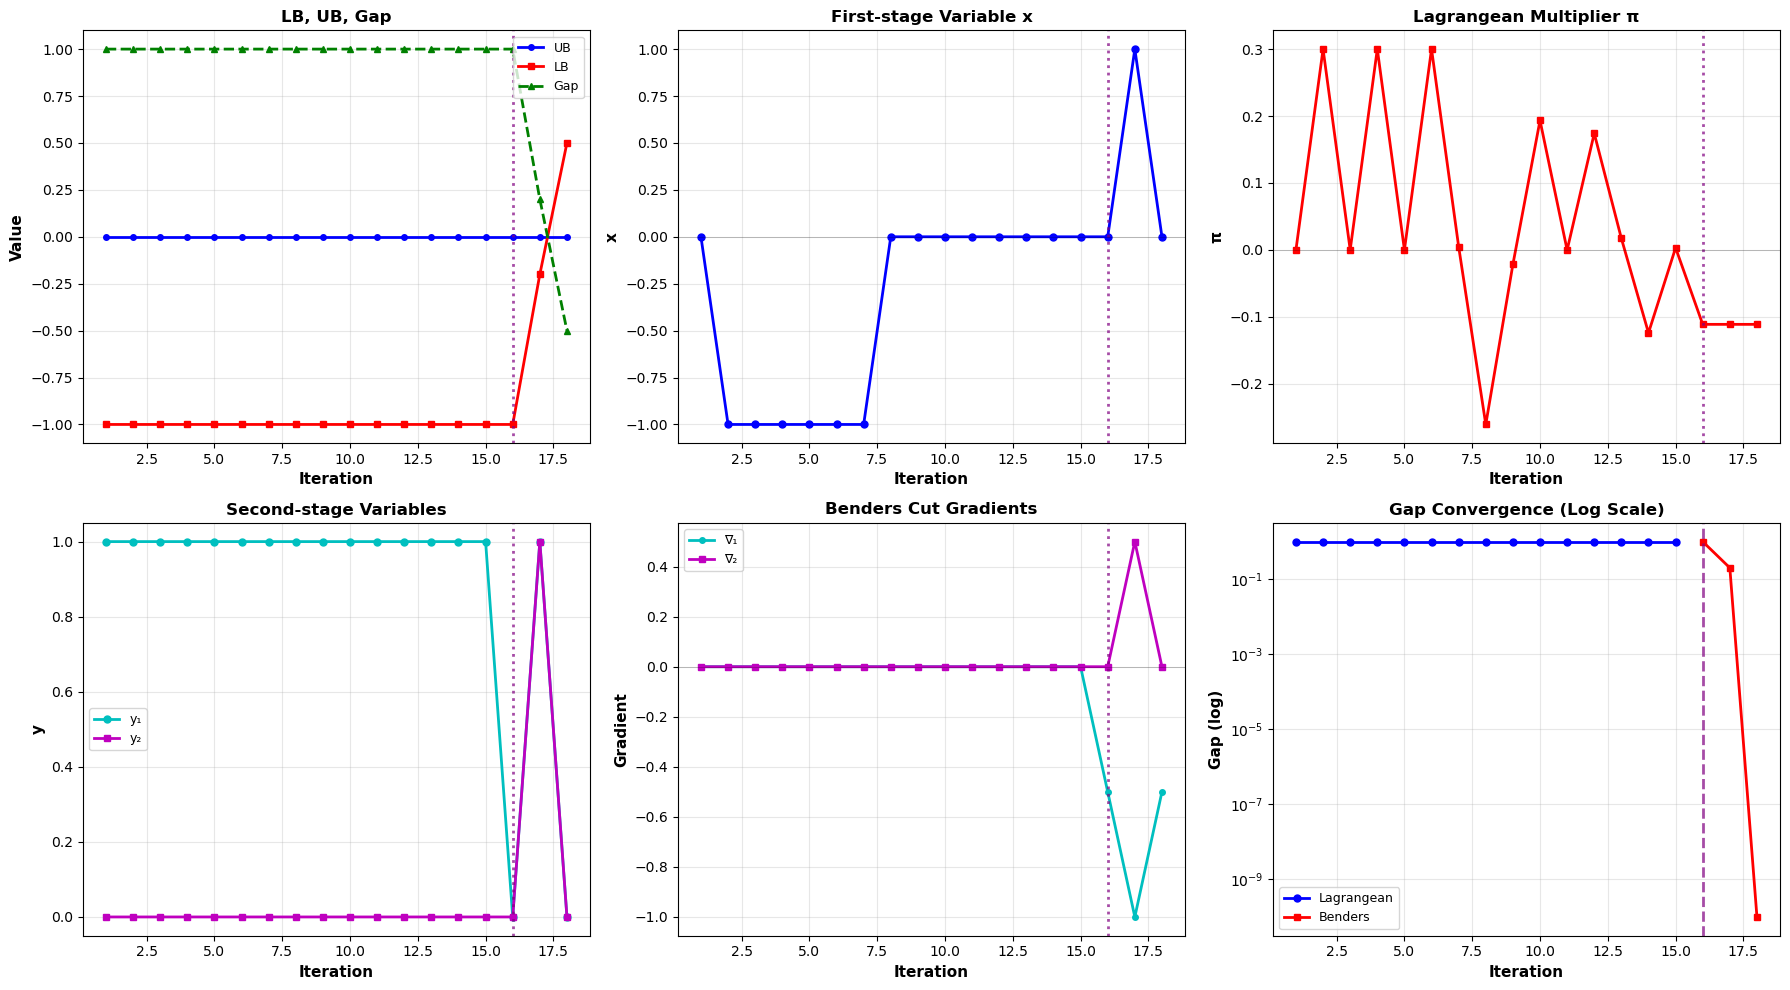

Done!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pyomo.environ import (
    ConcreteModel, Var, Param, Constraint, Objective, Expression,
    minimize, value, SolverFactory
)

########################################################
# 基础设置
########################################################

X_LO, X_HI = -1.0, 1.0
Y_LO, Y_HI = 0.0, 1.0

def solve_model_gurobi(model):
    opt = SolverFactory("gurobi")
    opt.options["NonConvex"] = 2
    opt.options["NumericFocus"] = 3
    opt.options["OutputFlag"] = 0
    res = opt.solve(model, tee=False)
    return res

########################################################
# Lagrangean子问题
########################################################

def solve_lagrangian_scenario1(pi_val):
    m = ConcreteModel()
    m.x = Var(bounds=(X_LO, X_HI), initialize=0.0)
    m.y = Var(bounds=(Y_LO, Y_HI), initialize=0.0)
    m.c1 = Constraint(expr=m.y**2 == m.x**2)
    m.obj = Objective(expr=-m.y + pi_val * m.x, sense=minimize)
    
    solve_model_gurobi(m)
    return value(m.obj), value(m.x), value(m.y), -value(m.y)

def solve_lagrangian_scenario2(pi_val):
    m = ConcreteModel()
    m.x = Var(bounds=(X_LO, X_HI), initialize=0.0)
    m.y = Var(bounds=(Y_LO, Y_HI), initialize=0.0)
    m.c1 = Constraint(expr=m.y**2 >= m.x)
    m.c2 = Constraint(expr=m.y**2 >= -m.x)
    m.obj = Objective(expr=m.y - pi_val * m.x, sense=minimize)
    
    solve_model_gurobi(m)
    return value(m.obj), value(m.x), value(m.y), value(m.y)

########################################################
# Benders子问题（改进的梯度计算）
########################################################

def solve_benders_scenario1(x_fixed):
    """场景1: y1 = |x|, cost = -|x|"""
    m = ConcreteModel()
    m.y = Var(bounds=(Y_LO, Y_HI), initialize=abs(x_fixed))
    m.c1 = Constraint(expr=m.y**2 == x_fixed**2)
    m.obj = Objective(expr=-m.y, sense=minimize)
    
    solve_model_gurobi(m)
    obj_val = value(m.obj)
    y_val = value(m.y)
    
    # 梯度计算（带数值保护）
    if abs(x_fixed) > 1e-4:
        gradient = -np.sign(x_fixed)
    else:
        # 在x≈0附近使用次梯度的保守估计
        gradient = -0.5  # 介于-1和0之间
    
    return obj_val, y_val, gradient

def solve_benders_scenario2(x_fixed):
    """场景2: y2 = sqrt(|x|), cost = sqrt(|x|)"""
    m = ConcreteModel()
    m.y = Var(bounds=(Y_LO, Y_HI), initialize=max(0, np.sqrt(abs(x_fixed))))
    m.c1 = Constraint(expr=m.y**2 >= x_fixed)
    m.c2 = Constraint(expr=m.y**2 >= -x_fixed)
    m.obj = Objective(expr=m.y, sense=minimize)
    
    solve_model_gurobi(m)
    obj_val = value(m.obj)
    y_val = value(m.y)
    
    # 梯度计算（带数值保护和截断）
    if abs(x_fixed) > 1e-3:
        # 正常情况
        gradient = np.sign(x_fixed) / (2.0 * np.sqrt(abs(x_fixed)))
        # 截断梯度，防止过大
        gradient = np.clip(gradient, -10.0, 10.0)
    elif abs(x_fixed) > 1e-6:
        # 接近0时使用更保守的估计
        gradient = np.sign(x_fixed) * 5.0  # 固定为较小的值
    else:
        # 非常接近0时，使用次梯度
        gradient = 0.0
    return obj_val, y_val, gradient

########################################################
# 使用有限差分验证梯度（调试用）
########################################################

def compute_gradient_finite_diff(x_center, delta=1e-4):
    """用有限差分计算梯度"""
    # 场景1
    obj1_plus, _, _ = solve_benders_scenario1(x_center + delta)
    obj1_minus, _, _ = solve_benders_scenario1(x_center - delta)
    grad1 = (obj1_plus - obj1_minus) / (2 * delta)
    
    # 场景2
    obj2_plus, _, _ = solve_benders_scenario2(x_center + delta)
    obj2_minus, _, _ = solve_benders_scenario2(x_center - delta)
    grad2 = (obj2_plus - obj2_minus) / (2 * delta)
    
    return grad1, grad2

########################################################
# Master问题
########################################################

class MasterProblem:
    def __init__(self):
        self.lagrangean_cuts = []
        self.benders_cuts = []
    
    def add_lagrangean_cut(self, w, a, b):
        self.lagrangean_cuts.append((w, a, b))
    
    def add_benders_cut(self, w, q, g, x_bar):
        self.benders_cuts.append((w, q, g, x_bar))
    
    def solve(self):
        m = ConcreteModel()
        m.x = Var(bounds=(X_LO, X_HI), initialize=0.0)
        m.eta1 = Var(bounds=(-1e3, 1e3), initialize=0.0)
        m.eta2 = Var(bounds=(-1e3, 1e3), initialize=0.0)
        
        # Lagrangean cuts
        m.lag_cuts = Constraint(range(len(self.lagrangean_cuts)))
        for i, (w, a, b) in enumerate(self.lagrangean_cuts):
            if w == 1:
                m.lag_cuts[i] = (m.eta1 >= a + b * m.x)
            else:
                m.lag_cuts[i] = (m.eta2 >= a + b * m.x)
        
        # Benders cuts
        m.ben_cuts = Constraint(range(len(self.benders_cuts)))
        for i, (w, q, g, x_bar) in enumerate(self.benders_cuts):
            if w == 1:
                m.ben_cuts[i] = (m.eta1 >= q + g * (m.x - x_bar))
            else:
                m.ben_cuts[i] = (m.eta2 >= q + g * (m.x - x_bar))
        
        m.obj = Objective(expr=m.eta1 + m.eta2, sense=minimize)
        
        solve_model_gurobi(m)
        return value(m.x), value(m.obj)

def compute_UB(x_val):
    obj1, _, _ = solve_benders_scenario1(x_val)
    obj2, _, _ = solve_benders_scenario2(x_val)
    return obj1 + obj2

########################################################
# 主算法（改进版）
########################################################

def run_decomposition_algorithm(
    max_lag_iter=15,
    max_ben_iter=25,
    verbose=True,
    use_finite_diff=False  # 是否使用有限差分
):
    master = MasterProblem()
    
    history = {
        'iteration': [],
        'phase': [],
        'LB': [],
        'UB': [],
        'gap': [],
        'x': [],
        'pi': [],
        'y1': [],
        'y2': [],
        'grad1': [],
        'grad2': []
    }
    
    global_iter = 0
    bestUB = np.inf
    bestLB = -np.inf
    
    # ===== Phase 1: Lagrangean =====
    pi = 0.0
    theta = 0.5
    alpha_cap = 0.3
    
    if verbose:
        print("\n" + "="*70)
        print("Phase 1: Lagrangean Iterations")
        print("="*70)
    
    for k in range(1, max_lag_iter + 1):
        global_iter += 1
        
        z1, x1, y1, base1 = solve_lagrangian_scenario1(pi)
        z2, x2, y2, base2 = solve_lagrangian_scenario2(pi)
        
        master.add_lagrangean_cut(1, z1, -pi)
        master.add_lagrangean_cut(2, z2, +pi)
        
        x_master, LB = master.solve()
        bestLB = max(bestLB, LB)
        
        UB = compute_UB(x_master)
        bestUB = min(bestUB, UB)
        gap = bestUB - bestLB
        
        history['iteration'].append(global_iter)
        history['phase'].append('Lagrangean')
        history['LB'].append(bestLB)
        history['UB'].append(bestUB)
        history['gap'].append(gap)
        history['x'].append(x_master)
        history['pi'].append(pi)
        history['y1'].append(y1)
        history['y2'].append(y2)
        history['grad1'].append(0)
        history['grad2'].append(0)
        
        g = x1 - x2
        alpha = min(theta * 1.0 / (g*g + 1e-12), alpha_cap)
        pi = np.clip(pi + alpha * g, -5.0, 5.0)
        theta *= 0.9
        
        if verbose:
            print(f"  Iter {global_iter:2d}: x={x_master:+.6f}, π={pi:+.5f}, "
                  f"LB={bestLB:+.6f}, UB={bestUB:+.6f}, gap={gap:.6f}")
    
    # ===== Phase 2: Benders =====
    if verbose:
        print("\n" + "="*70)
        print("Phase 2: Benders Iterations")
        print("="*70)
    
    for k in range(1, max_ben_iter + 1):
        global_iter += 1
        
        x_master, LB = master.solve()
        bestLB = max(bestLB, LB)
        
        # 求解Benders子问题
        if use_finite_diff and abs(x_master) < 0.01:
            # 在x接近0时使用有限差分
            grad1, grad2 = compute_gradient_finite_diff(x_master)
            obj1, y1, _ = solve_benders_scenario1(x_master)
            obj2, y2, _ = solve_benders_scenario2(x_master)
        else:
            obj1, y1, grad1 = solve_benders_scenario1(x_master)
            obj2, y2, grad2 = solve_benders_scenario2(x_master)
        
        UB = obj1 + obj2
        bestUB = min(bestUB, UB)
        gap = bestUB - bestLB
        
        history['iteration'].append(global_iter)
        history['phase'].append('Benders')
        history['LB'].append(bestLB)
        history['UB'].append(bestUB)
        history['gap'].append(gap)
        history['x'].append(x_master)
        history['pi'].append(pi)
        history['y1'].append(y1)
        history['y2'].append(y2)
        history['grad1'].append(grad1)
        history['grad2'].append(grad2)
        
        master.add_benders_cut(1, obj1, grad1, x_master)
        master.add_benders_cut(2, obj2, grad2, x_master)
        
        if verbose:
            print(f"  Iter {global_iter:2d}: x={x_master:+.6f}, y1={y1:.4f}, y2={y2:.4f}, "
                  f"grad=({grad1:+.2f},{grad2:+.2f}), "
                  f"LB={bestLB:+.6f}, UB={bestUB:+.6f}, gap={gap:.6f}")
        
        if gap < 1e-4:
            if verbose:
                print(f"\n✓ Converged! Gap = {gap:.8f}")
            break
    
    return bestLB, bestUB, x_master, history

########################################################
# 画图（增强版）
########################################################

def plot_convergence(history):
    phase_change_idx = None
    for i in range(1, len(history['phase'])):
        if history['phase'][i] != history['phase'][i-1]:
            phase_change_idx = i
            break
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    iterations = history['iteration']
    
    # 图1: LB/UB/Gap
    ax = axes[0, 0]
    ax.plot(iterations, history['UB'], 'b-', linewidth=2, label='UB', marker='o', markersize=4)
    ax.plot(iterations, history['LB'], 'r-', linewidth=2, label='LB', marker='s', markersize=4)
    ax.plot(iterations, history['gap'], 'g--', linewidth=2, label='Gap', marker='^', markersize=4)
    if phase_change_idx:
        ax.axvline(x=iterations[phase_change_idx], color='purple', linestyle=':', linewidth=2, alpha=0.7)
    ax.set_xlabel('Iteration', fontsize=11, fontweight='bold')
    ax.set_ylabel('Value', fontsize=11, fontweight='bold')
    ax.set_title('LB, UB, Gap', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    
    # 图2: x的演化
    ax = axes[0, 1]
    ax.plot(iterations, history['x'], 'b-', linewidth=2, marker='o', markersize=5)
    if phase_change_idx:
        ax.axvline(x=iterations[phase_change_idx], color='purple', linestyle=':', linewidth=2, alpha=0.7)
    ax.set_xlabel('Iteration', fontsize=11, fontweight='bold')
    ax.set_ylabel('x', fontsize=11, fontweight='bold')
    ax.set_title('First-stage Variable x', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
    
    # 图3: π的演化
    ax = axes[0, 2]
    ax.plot(iterations, history['pi'], 'r-', linewidth=2, marker='s', markersize=5)
    if phase_change_idx:
        ax.axvline(x=iterations[phase_change_idx], color='purple', linestyle=':', linewidth=2, alpha=0.7)
    ax.set_xlabel('Iteration', fontsize=11, fontweight='bold')
    ax.set_ylabel('π', fontsize=11, fontweight='bold')
    ax.set_title('Lagrangean Multiplier π', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
    
    # 图4: y1和y2
    ax = axes[1, 0]
    ax.plot(iterations, history['y1'], 'c-', linewidth=2, marker='o', markersize=5, label='y₁')
    ax.plot(iterations, history['y2'], 'm-', linewidth=2, marker='s', markersize=5, label='y₂')
    if phase_change_idx:
        ax.axvline(x=iterations[phase_change_idx], color='purple', linestyle=':', linewidth=2, alpha=0.7)
    ax.set_xlabel('Iteration', fontsize=11, fontweight='bold')
    ax.set_ylabel('y', fontsize=11, fontweight='bold')
    ax.set_title('Second-stage Variables', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    
    # 图5: 梯度演化
    ax = axes[1, 1]
    ax.plot(iterations, history['grad1'], 'c-', linewidth=2, marker='o', markersize=4, label='∇₁')
    ax.plot(iterations, history['grad2'], 'm-', linewidth=2, marker='s', markersize=4, label='∇₂')
    if phase_change_idx:
        ax.axvline(x=iterations[phase_change_idx], color='purple', linestyle=':', linewidth=2, alpha=0.7)
    ax.set_xlabel('Iteration', fontsize=11, fontweight='bold')
    ax.set_ylabel('Gradient', fontsize=11, fontweight='bold')
    ax.set_title('Benders Cut Gradients', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
    
    # 图6: Gap (log scale)
    ax = axes[1, 2]
    gaps = [max(g, 1e-10) for g in history['gap']]
    if phase_change_idx:
        lag_iters = iterations[:phase_change_idx]
        lag_gaps = gaps[:phase_change_idx]
        ax.semilogy(lag_iters, lag_gaps, 'b-o', linewidth=2, markersize=5, label='Lagrangean')
        
        ben_iters = iterations[phase_change_idx:]
        ben_gaps = gaps[phase_change_idx:]
        ax.semilogy(ben_iters, ben_gaps, 'r-s', linewidth=2, markersize=5, label='Benders')
        
        ax.axvline(x=iterations[phase_change_idx], color='purple', linestyle='--', linewidth=2, alpha=0.7)
    else:
        ax.semilogy(iterations, gaps, 'b-o', linewidth=2, markersize=5)
    
    ax.set_xlabel('Iteration', fontsize=11, fontweight='bold')
    ax.set_ylabel('Gap (log)', fontsize=11, fontweight='bold')
    ax.set_title('Gap Convergence (Log Scale)', fontsize=12, fontweight='bold')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=9)
    
    plt.tight_layout()
    plt.savefig('convergence_fixed.png', dpi=300, bbox_inches='tight')
    plt.show()

########################################################
# Main
########################################################

if __name__ == "__main__":
    LB, UB, x_opt, history = run_decomposition_algorithm(
        max_lag_iter=15,
        max_ben_iter=20,
        verbose=True,
        use_finite_diff=False  # 可以试试改成True
    )
    
    print("\n" + "="*70)
    print("FINAL RESULTS")
    print("="*70)
    print(f"Lower Bound:  {LB:+.8f}")
    print(f"Upper Bound:  {UB:+.8f}")
    print(f"Gap:          {UB - LB:.8f}")
    print(f"Optimal x:    {x_opt:+.8f}")
    print(f"Optimal obj:  {UB:.8f}")
    
    print("\nGenerating plots...")
    plot_convergence(history)
    print("Done!")


Phase 1: Lagrangean Iterations


  Iter  1: x=+0.0000, π=+0.3000, LB=-1.0000, UB=+0.0000, gap=1.0000
  Iter  2: x=-1.0000, π=+0.0000, LB=-1.0000, UB=+0.0000, gap=1.0000
  Iter  3: x=-1.0000, π=+0.3000, LB=-1.0000, UB=+0.0000, gap=1.0000
  Iter  4: x=-1.0000, π=+0.0000, LB=-1.0000, UB=+0.0000, gap=1.0000
  Iter  5: x=-1.0000, π=+0.3000, LB=-1.0000, UB=+0.0000, gap=1.0000

Phase 2: Benders Iterations
  Iter  6: x=-1.0000, y1=1.0000, y2=1.0000, LB=-1.0000, UB=+0.0000, gap=1.0000
  Iter  7: x=-1.0000, y1=1.0000, y2=1.0000, LB=+0.0000, UB=+0.0000, gap=0.0000

✓ Converged! Final gap = 0.000000

FINAL RESULTS
Lower Bound: +0.000000
Upper Bound: +0.000000
Gap:         0.000000
Optimal x:   -1.000000

Generating plots...


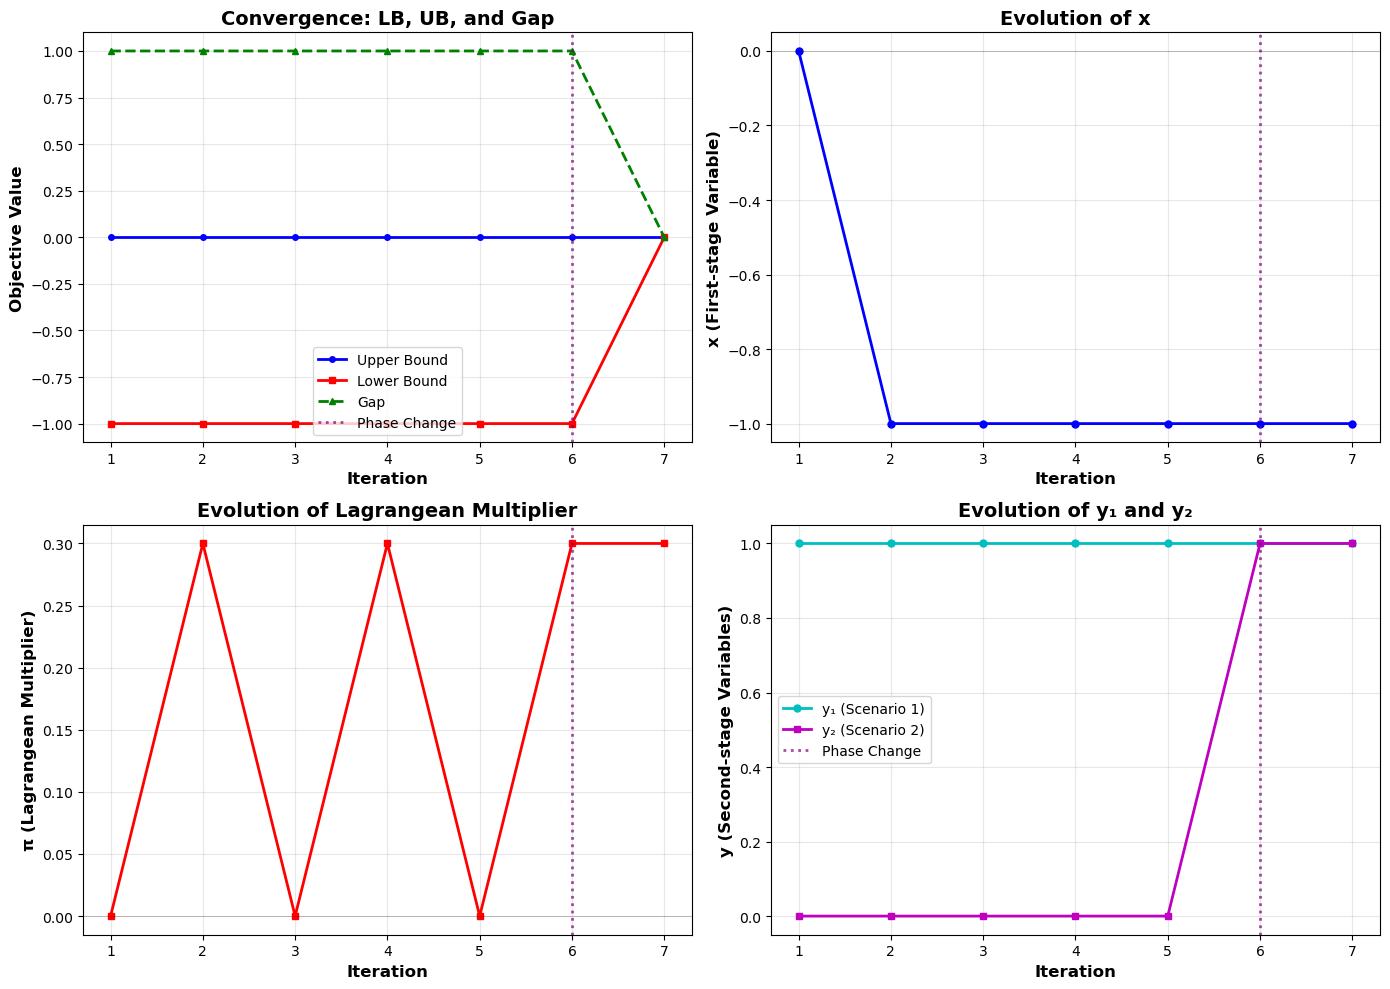

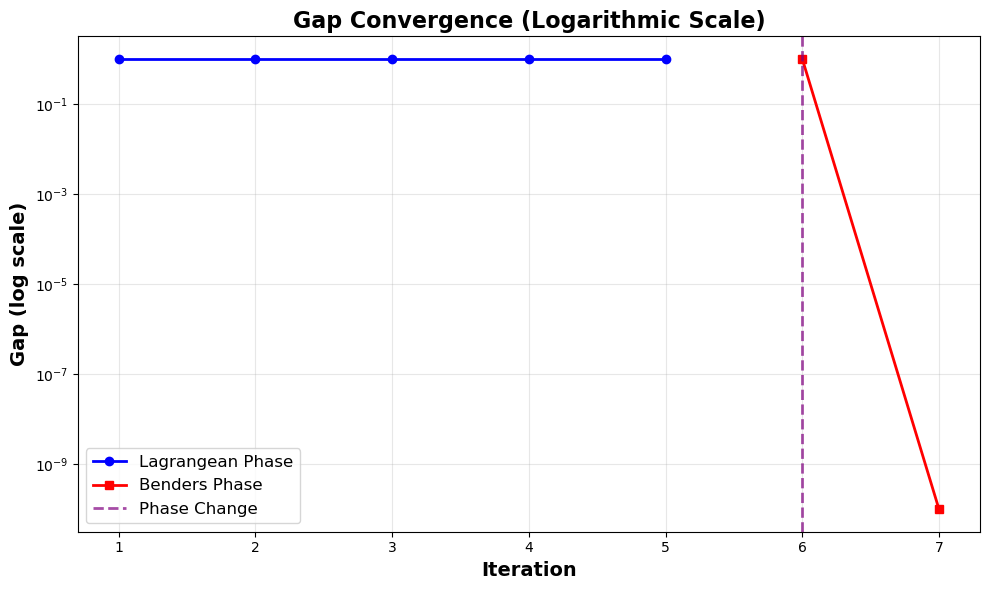

Plots saved!


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from pyomo.environ import (
    ConcreteModel, Var, Param, Constraint, Objective, Expression,
    minimize, value, SolverFactory
)

########################################################
# 1. 场景子问题定义（用于Lagrangean和Benders）
########################################################

X_LO, X_HI = -1.0, 1.0
Y_LO, Y_HI = 0.0, 1.0

def solve_model_gurobi(model):
    opt = SolverFactory("gurobi")
    opt.options["NonConvex"] = 2
    opt.options["NumericFocus"] = 3
    opt.options["OutputFlag"] = 0
    res = opt.solve(model, tee=False)
    return res

########################################################
# 2. Lagrangean子问题（x是变量）
########################################################

def solve_lagrangian_scenario1(pi_val):
    """场景1 Lagrangean: min -y1 + π·x, s.t. y1^2 = x^2"""
    m = ConcreteModel()
    m.x = Var(bounds=(X_LO, X_HI), initialize=0.0)
    m.y = Var(bounds=(Y_LO, Y_HI), initialize=0.0)
    m.c1 = Constraint(expr=m.y**2 == m.x**2)
    m.obj = Objective(expr=-m.y + pi_val * m.x, sense=minimize)
    
    solve_model_gurobi(m)
    return value(m.obj), value(m.x), value(m.y), -value(m.y)

def solve_lagrangian_scenario2(pi_val):
    """场景2 Lagrangean: min y2 - π·x, s.t. y2^2 ≥ |x|"""
    m = ConcreteModel()
    m.x = Var(bounds=(X_LO, X_HI), initialize=0.0)
    m.y = Var(bounds=(Y_LO, Y_HI), initialize=0.0)
    m.c1 = Constraint(expr=m.y**2 >= m.x)
    m.c2 = Constraint(expr=m.y**2 >= -m.x)
    m.obj = Objective(expr=m.y - pi_val * m.x, sense=minimize)
    
    solve_model_gurobi(m)
    return value(m.obj), value(m.x), value(m.y), value(m.y)

########################################################
# 3. Benders子问题（x是固定参数）
########################################################

def solve_benders_scenario1(x_fixed):
    """场景1 Benders: 固定x，min -y1 s.t. y1^2 = x^2"""
    m = ConcreteModel()
    m.y = Var(bounds=(Y_LO, Y_HI), initialize=abs(x_fixed))
    m.c1 = Constraint(expr=m.y**2 == x_fixed**2)
    m.obj = Objective(expr=-m.y, sense=minimize)
    
    solve_model_gurobi(m)
    obj_val = value(m.obj)
    y_val = value(m.y)
    
    # 计算次梯度（对x的偏导）
    if abs(x_fixed) > 1e-6:
        gradient = -np.sign(x_fixed)
    else:
        gradient = 0.0
    
    return obj_val, y_val, gradient

def solve_benders_scenario2(x_fixed):
    """场景2 Benders: 固定x，min y2 s.t. y2^2 ≥ |x|"""
    m = ConcreteModel()
    m.y = Var(bounds=(Y_LO, Y_HI), initialize=max(0, np.sqrt(abs(x_fixed))))
    m.c1 = Constraint(expr=m.y**2 >= x_fixed)
    m.c2 = Constraint(expr=m.y**2 >= -x_fixed)
    m.obj = Objective(expr=m.y, sense=minimize)
    
    solve_model_gurobi(m)
    obj_val = value(m.obj)
    y_val = value(m.y)
    
    # 计算次梯度
    if abs(x_fixed) > 1e-6:
        gradient = np.sign(x_fixed) / (2.0 * np.sqrt(abs(x_fixed)))
    else:
        gradient = 0.0
    
    return obj_val, y_val, gradient

########################################################
# 4. Master问题
########################################################

class MasterProblem:
    def __init__(self):
        self.lagrangean_cuts = []  # (w, a, b)
        self.benders_cuts = []      # (w, q, g, x_bar)
    
    def add_lagrangean_cut(self, w, a, b):
        """Lagrangean cut: eta_w >= a + b*x"""
        self.lagrangean_cuts.append((w, a, b))
    
    def add_benders_cut(self, w, q, g, x_bar):
        """Benders cut: eta_w >= q + g*(x - x_bar)"""
        self.benders_cuts.append((w, q, g, x_bar))
    
    def solve(self):
        m = ConcreteModel()
        m.x = Var(bounds=(X_LO, X_HI), initialize=0.0)
        m.eta1 = Var(bounds=(-1e3, 1e3), initialize=0.0)
        m.eta2 = Var(bounds=(-1e3, 1e3), initialize=0.0)
        
        # Lagrangean cuts
        m.lag_cuts = Constraint(range(len(self.lagrangean_cuts)))
        for i, (w, a, b) in enumerate(self.lagrangean_cuts):
            if w == 1:
                m.lag_cuts[i] = (m.eta1 >= a + b * m.x)
            else:
                m.lag_cuts[i] = (m.eta2 >= a + b * m.x)
        
        # Benders cuts
        m.ben_cuts = Constraint(range(len(self.benders_cuts)))
        for i, (w, q, g, x_bar) in enumerate(self.benders_cuts):
            if w == 1:
                m.ben_cuts[i] = (m.eta1 >= q + g * (m.x - x_bar))
            else:
                m.ben_cuts[i] = (m.eta2 >= q + g * (m.x - x_bar))
        
        m.obj = Objective(expr=m.eta1 + m.eta2, sense=minimize)
        
        solve_model_gurobi(m)
        return value(m.x), value(m.obj)

########################################################
# 5. 上界计算
########################################################

def compute_UB(x_val):
    """固定x，计算真实目标函数值"""
    obj1, _, _ = solve_benders_scenario1(x_val)
    obj2, _, _ = solve_benders_scenario2(x_val)
    return obj1 + obj2

########################################################
# 6. 完整算法（Lagrangean + Benders）
########################################################

def run_decomposition_algorithm(
    max_lag_iter=10,
    max_ben_iter=10,
    verbose=True
):
    master = MasterProblem()
    
    # 历史记录
    history = {
        'iteration': [],
        'phase': [],
        'LB': [],
        'UB': [],
        'gap': [],
        'x': [],
        'pi': [],
        'y1': [],
        'y2': []
    }
    
    global_iter = 0
    bestUB = np.inf
    bestLB = -np.inf
    
    # ===== Phase 1: Lagrangean Iterations =====
    pi = 0.0
    theta = 0.5
    alpha_cap = 0.3
    
    if verbose:
        print("\n" + "="*60)
        print("Phase 1: Lagrangean Iterations")
        print("="*60)
    
    for k in range(1, max_lag_iter + 1):
        global_iter += 1
        
        # 求解Lagrangean子问题
        z1, x1, y1, base1 = solve_lagrangian_scenario1(pi)
        z2, x2, y2, base2 = solve_lagrangian_scenario2(pi)
        
        # 添加Lagrangean cuts
        master.add_lagrangean_cut(1, z1, -pi)
        master.add_lagrangean_cut(2, z2, +pi)
        
        # 求解master获取x和LB
        x_master, LB = master.solve()
        bestLB = max(bestLB, LB)
        
        # 计算UB
        UB = compute_UB(x_master)
        bestUB = min(bestUB, UB)
        
        gap = bestUB - bestLB
        
        # 记录历史
        history['iteration'].append(global_iter)
        history['phase'].append('Lagrangean')
        history['LB'].append(bestLB)
        history['UB'].append(bestUB)
        history['gap'].append(gap)
        history['x'].append(x_master)
        history['pi'].append(pi)
        history['y1'].append(y1)
        history['y2'].append(y2)
        
        # 更新乘子
        g = x1 - x2
        alpha = min(theta * 1.0 / (g*g + 1e-12), alpha_cap)
        pi = np.clip(pi + alpha * g, -5.0, 5.0)
        theta *= 0.9
        
        if verbose:
            print(f"  Iter {global_iter:2d}: x={x_master:+.4f}, π={pi:+.4f}, "
                  f"LB={bestLB:+.4f}, UB={bestUB:+.4f}, gap={gap:.4f}")
    
    # ===== Phase 2: Benders Iterations =====
    if verbose:
        print("\n" + "="*60)
        print("Phase 2: Benders Iterations")
        print("="*60)
    
    for k in range(1, max_ben_iter + 1):
        global_iter += 1
        
        # 求解master
        x_master, LB = master.solve()
        bestLB = max(bestLB, LB)
        
        # 求解Benders子问题（固定x）
        obj1, y1, grad1 = solve_benders_scenario1(x_master)
        obj2, y2, grad2 = solve_benders_scenario2(x_master)
        
        # 计算上界
        UB = obj1 + obj2
        bestUB = min(bestUB, UB)
        
        gap = bestUB - bestLB
        
        # 记录历史
        history['iteration'].append(global_iter)
        history['phase'].append('Benders')
        history['LB'].append(bestLB)
        history['UB'].append(bestUB)
        history['gap'].append(gap)
        history['x'].append(x_master)
        history['pi'].append(pi)  # Benders阶段π不再更新
        history['y1'].append(y1)
        history['y2'].append(y2)
        
        # 添加Benders cuts
        master.add_benders_cut(1, obj1, grad1, x_master)
        master.add_benders_cut(2, obj2, grad2, x_master)
        
        if verbose:
            print(f"  Iter {global_iter:2d}: x={x_master:+.4f}, y1={y1:.4f}, y2={y2:.4f}, "
                  f"LB={bestLB:+.4f}, UB={bestUB:+.4f}, gap={gap:.4f}")
        
        if gap < 1e-3:
            if verbose:
                print(f"\n✓ Converged! Final gap = {gap:.6f}")
            break
    
    return bestLB, bestUB, x_master, history

########################################################
# 7. 画图函数
########################################################

def plot_convergence(history):
    """画出算法收敛过程"""
    
    # 找到阶段分界点
    phase_change_idx = None
    for i in range(1, len(history['phase'])):
        if history['phase'][i] != history['phase'][i-1]:
            phase_change_idx = i
            break
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # ===== 图1: LB/UB/Gap收敛 =====
    ax = axes[0, 0]
    iterations = history['iteration']
    
    ax.plot(iterations, history['UB'], 'b-', linewidth=2, label='Upper Bound', marker='o', markersize=4)
    ax.plot(iterations, history['LB'], 'r-', linewidth=2, label='Lower Bound', marker='s', markersize=4)
    ax.plot(iterations, history['gap'], 'g--', linewidth=2, label='Gap', marker='^', markersize=4)
    
    # 标记阶段分界线
    if phase_change_idx:
        ax.axvline(x=iterations[phase_change_idx], color='purple', 
                   linestyle=':', linewidth=2, alpha=0.7, label='Phase Change')
    
    ax.set_xlabel('Iteration', fontsize=12, fontweight='bold')
    ax.set_ylabel('Objective Value', fontsize=12, fontweight='bold')
    ax.set_title('Convergence: LB, UB, and Gap', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc='best')
    
    # ===== 图2: x的演化 =====
    ax = axes[0, 1]
    ax.plot(iterations, history['x'], 'b-', linewidth=2, marker='o', markersize=5)
    
    if phase_change_idx:
        ax.axvline(x=iterations[phase_change_idx], color='purple', 
                   linestyle=':', linewidth=2, alpha=0.7)
    
    ax.set_xlabel('Iteration', fontsize=12, fontweight='bold')
    ax.set_ylabel('x (First-stage Variable)', fontsize=12, fontweight='bold')
    ax.set_title('Evolution of x', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
    
    # ===== 图3: π的演化 =====
    ax = axes[1, 0]
    ax.plot(iterations, history['pi'], 'r-', linewidth=2, marker='s', markersize=5)
    
    if phase_change_idx:
        ax.axvline(x=iterations[phase_change_idx], color='purple', 
                   linestyle=':', linewidth=2, alpha=0.7)
    
    ax.set_xlabel('Iteration', fontsize=12, fontweight='bold')
    ax.set_ylabel('π (Lagrangean Multiplier)', fontsize=12, fontweight='bold')
    ax.set_title('Evolution of Lagrangean Multiplier', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
    
    # ===== 图4: y1和y2的演化 =====
    ax = axes[1, 1]
    ax.plot(iterations, history['y1'], 'c-', linewidth=2, marker='o', 
            markersize=5, label='y₁ (Scenario 1)')
    ax.plot(iterations, history['y2'], 'm-', linewidth=2, marker='s', 
            markersize=5, label='y₂ (Scenario 2)')
    
    if phase_change_idx:
        ax.axvline(x=iterations[phase_change_idx], color='purple', 
                   linestyle=':', linewidth=2, alpha=0.7, label='Phase Change')
    
    ax.set_xlabel('Iteration', fontsize=12, fontweight='bold')
    ax.set_ylabel('y (Second-stage Variables)', fontsize=12, fontweight='bold')
    ax.set_title('Evolution of y₁ and y₂', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc='best')
    
    plt.tight_layout()
    plt.savefig('convergence_plot.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_gap_log_scale(history):
    """用对数刻度画gap收敛"""
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    iterations = history['iteration']
    gaps = [max(g, 1e-10) for g in history['gap']]  # 避免log(0)
    
    # 找到阶段分界点
    phase_change_idx = None
    for i in range(1, len(history['phase'])):
        if history['phase'][i] != history['phase'][i-1]:
            phase_change_idx = i
            break
    
    # Lagrangean阶段
    if phase_change_idx:
        lag_iters = iterations[:phase_change_idx]
        lag_gaps = gaps[:phase_change_idx]
        ax.semilogy(lag_iters, lag_gaps, 'b-o', linewidth=2, 
                    markersize=6, label='Lagrangean Phase')
        
        # Benders阶段
        ben_iters = iterations[phase_change_idx:]
        ben_gaps = gaps[phase_change_idx:]
        ax.semilogy(ben_iters, ben_gaps, 'r-s', linewidth=2, 
                    markersize=6, label='Benders Phase')
        
        # 分界线
        ax.axvline(x=iterations[phase_change_idx], color='purple', 
                   linestyle='--', linewidth=2, alpha=0.7, label='Phase Change')
    else:
        ax.semilogy(iterations, gaps, 'b-o', linewidth=2, markersize=6)
    
    ax.set_xlabel('Iteration', fontsize=14, fontweight='bold')
    ax.set_ylabel('Gap (log scale)', fontsize=14, fontweight='bold')
    ax.set_title('Gap Convergence (Logarithmic Scale)', fontsize=16, fontweight='bold')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=12, loc='best')
    
    plt.tight_layout()
    plt.savefig('gap_convergence_log.png', dpi=300, bbox_inches='tight')
    plt.show()

########################################################
# 8. Main
########################################################

if __name__ == "__main__":
    LB, UB, x_opt, history = run_decomposition_algorithm(
        max_lag_iter=5,
        max_ben_iter=5,
        verbose=True
    )
    
    print("\n" + "="*60)
    print("FINAL RESULTS")
    print("="*60)
    print(f"Lower Bound: {LB:+.6f}")
    print(f"Upper Bound: {UB:+.6f}")
    print(f"Gap:         {UB - LB:.6f}")
    print(f"Optimal x:   {x_opt:+.6f}")
    
    # 画图
    print("\nGenerating plots...")
    plot_convergence(history)
    plot_gap_log_scale(history)
    print("Plots saved!")

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from pyomo.environ import (
    ConcreteModel, Var, Param, Constraint, Objective, Expression,
    minimize, value, SolverFactory
)

########################################################
# 1. 场景子问题定义（用于Lagrangean和Benders）
########################################################

X_LO, X_HI = -1.0, 1.0
Y_LO, Y_HI = 0.0, 1.0

def solve_model_gurobi(model):
    opt = SolverFactory("gurobi")
    opt.options["NonConvex"] = 2
    opt.options["NumericFocus"] = 3
    opt.options["OutputFlag"] = 0
    res = opt.solve(model, tee=False)
    return res

########################################################
# 2. Lagrangean子问题（x是变量）
########################################################

def solve_lagrangian_scenario1(pi_val):
    """场景1 Lagrangean: min -y1 + π·x, s.t. y1^2 = x^2"""
    m = ConcreteModel()
    m.x = Var(bounds=(X_LO, X_HI), initialize=0.0)
    m.y = Var(bounds=(Y_LO, Y_HI), initialize=0.0)
    m.c1 = Constraint(expr=m.y**2 == m.x**2)
    m.obj = Objective(expr=-m.y + pi_val * m.x, sense=minimize)
    
    solve_model_gurobi(m)
    return value(m.obj), value(m.x), value(m.y), -value(m.y)

def solve_lagrangian_scenario2(pi_val):
    """场景2 Lagrangean: min y2 - π·x, s.t. y2^2 ≥ |x|"""
    m = ConcreteModel()
    m.x = Var(bounds=(X_LO, X_HI), initialize=0.0)
    m.y = Var(bounds=(Y_LO, Y_HI), initialize=0.0)
    m.c1 = Constraint(expr=m.y**2 >= m.x)
    m.c2 = Constraint(expr=m.y**2 >= -m.x)
    m.obj = Objective(expr=m.y - pi_val * m.x, sense=minimize)
    
    solve_model_gurobi(m)
    return value(m.obj), value(m.x), value(m.y), value(m.y)

########################################################
# 3. Benders子问题（x是固定参数）
########################################################

def solve_benders_scenario1(x_fixed):
    """场景1 Benders: 固定x，min -y1 s.t. y1^2 = x^2"""
    m = ConcreteModel()
    m.y = Var(bounds=(Y_LO, Y_HI), initialize=abs(x_fixed))
    m.c1 = Constraint(expr=m.y**2 == x_fixed**2)
    m.obj = Objective(expr=-m.y, sense=minimize)
    
    solve_model_gurobi(m)
    obj_val = value(m.obj)
    y_val = value(m.y)
    
    # 计算次梯度（对x的偏导）
    # y1 = |x|, cost = -|x|
    # ∂cost/∂x = -sign(x) if x≠0
    if abs(x_fixed) > 1e-6:
        gradient = -np.sign(x_fixed)
    else:
        gradient = 0.0  # 次梯度，取0
    
    return obj_val, y_val, gradient

def solve_benders_scenario2(x_fixed):
    """场景2 Benders: 固定x，min y2 s.t. y2^2 ≥ |x|"""
    m = ConcreteModel()
    m.y = Var(bounds=(Y_LO, Y_HI), initialize=max(0, np.sqrt(abs(x_fixed))))
    m.c1 = Constraint(expr=m.y**2 >= x_fixed)
    m.c2 = Constraint(expr=m.y**2 >= -x_fixed)
    m.obj = Objective(expr=m.y, sense=minimize)
    
    solve_model_gurobi(m)
    obj_val = value(m.obj)
    y_val = value(m.y)
    
    # 计算次梯度
    # y2 = sqrt(|x|), cost = sqrt(|x|)
    # ∂cost/∂x = sign(x)/(2*sqrt(|x|)) if x≠0
    if abs(x_fixed) > 1e-6:
        gradient = np.sign(x_fixed) / (2.0 * np.sqrt(abs(x_fixed)))
    else:
        gradient = 0.0
    
    return obj_val, y_val, gradient

########################################################
# 4. Master问题
########################################################

class MasterProblem:
    def __init__(self):
        self.lagrangean_cuts = []  # (w, a, b)
        self.benders_cuts = []      # (w, q, g, x_bar)
    
    def add_lagrangean_cut(self, w, a, b):
        """Lagrangean cut: eta_w >= a + b*x"""
        self.lagrangean_cuts.append((w, a, b))
    
    def add_benders_cut(self, w, q, g, x_bar):
        """Benders cut: eta_w >= q + g*(x - x_bar)"""
        self.benders_cuts.append((w, q, g, x_bar))
    
    def solve(self):
        m = ConcreteModel()
        m.x = Var(bounds=(X_LO, X_HI), initialize=0.0)
        m.eta1 = Var(bounds=(-1e3, 1e3), initialize=0.0)
        m.eta2 = Var(bounds=(-1e3, 1e3), initialize=0.0)
        
        # Lagrangean cuts
        m.lag_cuts = Constraint(range(len(self.lagrangean_cuts)))
        for i, (w, a, b) in enumerate(self.lagrangean_cuts):
            if w == 1:
                m.lag_cuts[i] = (m.eta1 >= a + b * m.x)
            else:
                m.lag_cuts[i] = (m.eta2 >= a + b * m.x)
        
        # Benders cuts
        m.ben_cuts = Constraint(range(len(self.benders_cuts)))
        for i, (w, q, g, x_bar) in enumerate(self.benders_cuts):
            if w == 1:
                m.ben_cuts[i] = (m.eta1 >= q + g * (m.x - x_bar))
            else:
                m.ben_cuts[i] = (m.eta2 >= q + g * (m.x - x_bar))
        
        m.obj = Objective(expr=m.eta1 + m.eta2, sense=minimize)
        
        solve_model_gurobi(m)
        return value(m.x), value(m.obj)

########################################################
# 5. 上界计算
########################################################

def compute_UB(x_val):
    """固定x，计算真实目标函数值"""
    obj1, _, _ = solve_benders_scenario1(x_val)
    obj2, _, _ = solve_benders_scenario2(x_val)
    return obj1 + obj2

########################################################
# 6. 完整算法（Lagrangean + Benders）
########################################################

def run_decomposition_algorithm(
    max_lag_iter=10,
    max_ben_iter=10,
    verbose=True
):
    master = MasterProblem()
    
    # ===== Phase 1: Lagrangean Iterations =====
    pi = 0.0
    theta = 0.5
    alpha_cap = 0.3
    
    if verbose:
        print("\n" + "="*60)
        print("Phase 1: Lagrangean Iterations")
        print("="*60)
    
    for k in range(1, max_lag_iter + 1):
        # 求解Lagrangean子问题
        z1, x1, y1, base1 = solve_lagrangian_scenario1(pi)
        z2, x2, y2, base2 = solve_lagrangian_scenario2(pi)
        
        # 添加Lagrangean cuts
        master.add_lagrangean_cut(1, z1, -pi)
        master.add_lagrangean_cut(2, z2, +pi)
        
        # 更新乘子
        g = x1 - x2
        alpha = min(theta * 1.0 / (g*g + 1e-12), alpha_cap)
        pi = np.clip(pi + alpha * g, -5.0, 5.0)
        theta *= 0.9
        
        if verbose and k % 3 == 0:
            print(f"  Lag iter {k}: x1={x1:.4f}, x2={x2:.4f}, π={pi:.4f}")
    
    # ===== Phase 2: Benders Iterations =====
    if verbose:
        print("\n" + "="*60)
        print("Phase 2: Benders Iterations")
        print("="*60)
    
    bestUB = np.inf
    bestLB = -np.inf
    
    for k in range(1, max_ben_iter + 1):
        # 求解master
        x_master, LB = master.solve()
        bestLB = max(bestLB, LB)
        
        # 求解Benders子问题（固定x）
        obj1, y1, grad1 = solve_benders_scenario1(x_master)
        obj2, y2, grad2 = solve_benders_scenario2(x_master)
        
        # 计算上界
        UB = obj1 + obj2
        bestUB = min(bestUB, UB)
        
        # 添加Benders cuts
        master.add_benders_cut(1, obj1, grad1, x_master)
        master.add_benders_cut(2, obj2, grad2, x_master)
        
        gap = bestUB - bestLB
        
        if verbose:
            print(f"  Ben iter {k}: x={x_master:+.4f}, y1={y1:.4f}, y2={y2:.4f}, "
                  f"LB={LB:+.4f}, UB={UB:+.4f}, gap={gap:.4f}")
        
        if gap < 1e-3:
            if verbose:
                print(f"\n✓ Converged! Final gap = {gap:.6f}")
            break
    
    return bestLB, bestUB, x_master

########################################################
# 7. Main
########################################################

if __name__ == "__main__":
    LB, UB, x_opt = run_decomposition_algorithm(
        max_lag_iter=15,
        max_ben_iter=20,
        verbose=True
    )
    
    print("\n" + "="*60)
    print("FINAL RESULTS")
    print("="*60)
    print(f"Lower Bound: {LB:+.6f}")
    print(f"Upper Bound: {UB:+.6f}")
    print(f"Gap:         {UB - LB:.6f}")
    print(f"Optimal x:   {x_opt:+.6f}")


Phase 1: Lagrangean Iterations
  Lag iter 3: x1=1.0000, x2=0.0000, π=0.3000
  Lag iter 6: x1=-1.0000, x2=0.0000, π=0.0048
  Lag iter 9: x1=1.0000, x2=0.0000, π=0.1934
  Lag iter 12: x1=-1.0000, x2=0.0000, π=0.0171
  Lag iter 15: x1=-1.0000, x2=0.0000, π=-0.1114

Phase 2: Benders Iterations
  Ben iter 1: x=+0.0000, y1=0.0000, y2=0.0000, LB=-1.0000, UB=+0.0000, gap=1.0000
  Ben iter 2: x=+0.0000, y1=0.0000, y2=0.0000, LB=+0.0000, UB=+0.0000, gap=0.0000

✓ Converged! Final gap = 0.000000

FINAL RESULTS
Lower Bound: +0.000000
Upper Bound: +0.000000
Gap:         0.000000
Optimal x:   +0.000000


[iter 01] y1=-0.200000, y2=+0.000000, y_shared=-0.200000 | LB=-6.072136e-01 | UB=+0.000000e+00 | gap=6.072e-01 | pi=+7.400000e-01, alpha=3.000e-01, theta=0.500
[iter 02] y1=-0.200000, y2=+0.000000, y_shared=+0.000000 | LB=-5.952136e-01 | UB=+0.000000e+00 | gap=5.952e-01 | pi=+6.800000e-01, alpha=3.000e-01, theta=0.500
[iter 03] y1=-0.200000, y2=+0.000000, y_shared=+0.000000 | LB=-5.832136e-01 | UB=+0.000000e+00 | gap=5.832e-01 | pi=+6.200000e-01, alpha=3.000e-01, theta=0.500
[iter 04] y1=-0.200000, y2=+0.000000, y_shared=+0.000000 | LB=-5.712136e-01 | UB=+0.000000e+00 | gap=5.712e-01 | pi=+5.600000e-01, alpha=3.000e-01, theta=0.500
[iter 05] y1=-0.200000, y2=+0.000000, y_shared=+0.000000 | LB=-5.592136e-01 | UB=+0.000000e+00 | gap=5.592e-01 | pi=+5.000000e-01, alpha=3.000e-01, theta=0.500
[iter 06] y1=-0.200000, y2=+0.000000, y_shared=+0.000000 | LB=-5.472136e-01 | UB=+0.000000e+00 | gap=5.472e-01 | pi=+4.400000e-01, alpha=3.000e-01, theta=0.500
[iter 07] y1=-0.200000, y2=+0.000000, y_

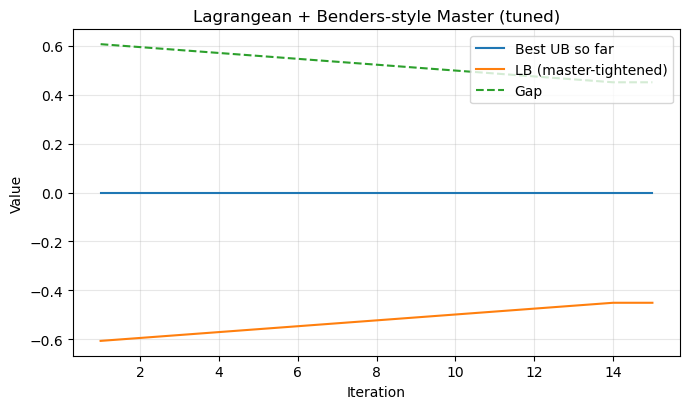

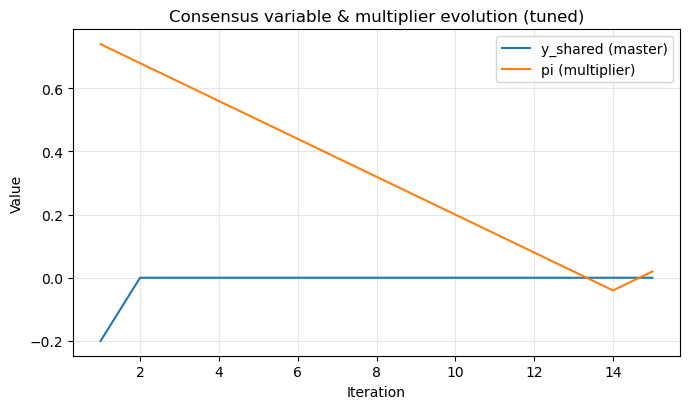

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from pyomo.environ import (
    ConcreteModel, Var, Param, Constraint, Objective, Expression,
    minimize, value, SolverFactory
)

########################################################
# 1. 两个场景的子问题模型 (带更宽的 y 边界 [-0.5,0.5])
########################################################

Y_LO = -0.2
Y_HI =  0.2

def build_scenario1():
    m = ConcreteModel()
    # 本场景自己的 y1
    m.y = Var(bounds=(Y_LO, Y_HI), initialize=0.0)
    m.x1 = Var(bounds=(0, 1), initialize=0.0)
    m.x11 = Var(bounds=(0, None), initialize=0.0)

    # 非凸关系:
    # x11^2 == y^2
    m.c1 = Constraint(expr=m.x11**2 == m.y**2)
    # x11 == (x1)^2
    m.c2 = Constraint(expr=m.x11 == m.x1**2)

    # 原始成本(不含乘子):  minimize -x1
    m.base_cost = Expression(expr= - m.x1 )

    # 拉格朗日乘子 π (mutable Param)
    m.pi = Param(initialize=0.0, mutable=True)

    # Lagrangean 目标: base_cost + π * y
    m.obj = Objective(expr=m.base_cost + m.pi * m.y, sense=minimize)
    return m


def build_scenario2():
    m = ConcreteModel()
    # 本场景自己的 y2
    m.y  = Var(bounds=(Y_LO, Y_HI), initialize=0.0)
    m.x2 = Var(bounds=(0, 1), initialize=0.0)

    # 非凸约束:
    # x2^2 >= y
    # x2^2 >= -y
    m.c1 = Constraint(expr=m.x2**2 >= m.y)
    m.c2 = Constraint(expr=m.x2**2 >= -m.y)

    # 原始成本(不含乘子): minimize x2
    m.base_cost = Expression(expr= m.x2 )

    m.pi = Param(initialize=0.0, mutable=True)

    # Lagrangean 目标: base_cost - π * y
    m.obj = Objective(expr=m.base_cost - m.pi * m.y, sense=minimize)
    return m


########################################################
# 2. Gurobi 求解子问题 / master
########################################################

def solve_model_gurobi(model):
    opt = SolverFactory("gurobi")
    # 允许非凸二次项 & 稳定数值
    opt.options["NonConvex"] = 2           # 关键
    opt.options["NumericFocus"] = 3        # 稳一点
    opt.options["OutputFlag"] = 0          # 静音
    res = opt.solve(model, tee=False)
    return res


def solve_lagrangian_subproblem(model, pi_val):
    """
    给定 π (拉格朗日乘子)，解场景子问题:
    返回:
        z_star: Lagrangean 目标的最优值
        y_star: 该场景局部 y 的解
        baseval: 原始成本(不含 π*y)
    """
    model.pi.value = pi_val
    solve_model_gurobi(model)
    z_star  = value(model.obj)
    y_star  = value(model.y)
    baseval = value(model.base_cost)
    return z_star, y_star, baseval


########################################################
# 3. master 问题管理器
#
# master变量:
#   y_shared  (所有场景同意的一阶段/共识变量)
#   eta1, eta2 (每个场景的代价上界)
#
# master目标:
#   minimize eta1 + eta2
#
# master约束 = 一堆cut:
#   eta_w >= a + b * y_shared
#   (Lagrangean cuts; w in {1,2})
########################################################

class MasterProblem:
    def __init__(self):
        # 保存所有 cut，元素是 (w, a, b) meaning:
        #   eta_w >= a + b*y_shared
        self.cuts = []

    def add_cut(self, w, a, b):
        self.cuts.append((w, a, b))

    def build_pyomo(self):
        m = ConcreteModel()

        # 全局共享y (同样放宽边界)
        m.y_shared = Var(bounds=(Y_LO, Y_HI), initialize=0.0)

        # 每个场景的η
        m.eta1 = Var(bounds=(-1e3, 1e3), initialize=0.0)
        m.eta2 = Var(bounds=(-1e3, 1e3), initialize=0.0)

        # 逐条创建 cut
        m.cut_constrs = Constraint(range(len(self.cuts)))
        for i,(w,a,b) in enumerate(self.cuts):
            if w == 1:
                # eta1 >= a + b*y_shared
                m.cut_constrs[i] = ( m.eta1 >= a + b*m.y_shared )
            else:
                # eta2 >= a + b*y_shared
                m.cut_constrs[i] = ( m.eta2 >= a + b*m.y_shared )

        # 目标: min eta1 + eta2
        m.obj = Objective(expr=m.eta1 + m.eta2, sense=minimize)
        return m


def solve_master_and_get_y(master_mgr):
    """
    构建 master, 用 Gurobi 解 (LP/QP 线性的)。
    返回:
        y_shared_val : master给出的全局共享y
        LB_val       : master的下界 (eta1+eta2)
    """
    M = master_mgr.build_pyomo()
    solve_model_gurobi(M)
    y_shared_val = value(M.y_shared)
    LB_val       = value(M.obj)
    return y_shared_val, LB_val


########################################################
# 4. 给定 y_shared (全局y)，算一个真实可行上界 UB
#
# - 把两个场景都强行用同一个 y_shared
# - 各自最优调 x1 / x2
# - 返回 z1+z2 (原始成本之和)
########################################################

def compute_feasible_UB_at_y(ybar):
    # 场景1: min -x1 s.t. x11^2 = ybar^2, x11 = x1^2
    m1 = ConcreteModel()
    m1.yfix  = Param(initialize=ybar, mutable=False)
    m1.x1    = Var(bounds=(0, 1), initialize=0.0)
    m1.x11   = Var(bounds=(0, None), initialize=0.0)

    m1.c1 = Constraint(expr=m1.x11**2 == m1.yfix**2)
    m1.c2 = Constraint(expr=m1.x11 == m1.x1**2)

    m1.obj = Objective(expr= - m1.x1, sense=minimize)

    # 场景2: min x2 s.t. x2^2 >= ybar, x2^2 >= -ybar
    m2 = ConcreteModel()
    m2.yfix = Param(initialize=ybar, mutable=False)
    m2.x2   = Var(bounds=(0, 1), initialize=0.0)

    m2.c1 = Constraint(expr=m2.x2**2 >= m2.yfix)
    m2.c2 = Constraint(expr=m2.x2**2 >= -m2.yfix)

    m2.obj = Objective(expr= m2.x2, sense=minimize)

    solve_model_gurobi(m1)
    solve_model_gurobi(m2)

    z1 = value(m1.obj)
    z2 = value(m2.obj)
    return z1 + z2


########################################################
# 5. 外层循环 (带更激进的参数)
#
#   - 初始 pi0=0.8 让两个场景一开始就强烈不同意
#   - alpha_cap=0.3 步长更大
#   - momentum_beta=0.0 去掉动量避免弹簧振荡
#   - theta 衰减更激进: gap一旦没变好，theta/=2
########################################################

def run_full_loop(
    max_iter=30,
    pi0=0.8,
    theta0=0.5,
    alpha_cap=0.3,
    momentum_beta=0.0,
    verbose=True
):
    scen1 = build_scenario1()
    scen2 = build_scenario2()

    master_mgr = MasterProblem()

    pi = pi0
    pi_prev = pi0
    theta = theta0

    last_gap = None
    bestUB  = np.inf

    LB_hist  = []
    UB_hist  = []
    GAP_hist = []
    y_hist   = []
    pi_hist  = []

    for k in range(1, max_iter+1):
        # ---- (1) solve Lagrangean subproblems with current pi
        z1_star, y1_star, base1 = solve_lagrangian_subproblem(scen1, pi)
        z2_star, y2_star, base2 = solve_lagrangian_subproblem(scen2, pi)

        LB_lag = z1_star + z2_star  # "raw" Lagrangean lower bound

        # ---- (2) add new cuts to master
        # 场景1 cut: eta1 >= z1_star - pi * y_shared
        master_mgr.add_cut(w=1, a=z1_star, b= -pi)
        # 场景2 cut: eta2 >= z2_star + pi * y_shared
        master_mgr.add_cut(w=2, a=z2_star, b= +pi)

        # ---- (3) solve master -> get y_shared and tightened LB
        y_shared, LB_master = solve_master_and_get_y(master_mgr)
        LB_effective = max(LB_lag, LB_master)

        # ---- (4) feasible UB from that shared y
        UB_val = compute_feasible_UB_at_y(y_shared)
        if UB_val < bestUB:
            bestUB = UB_val

        gap_now = bestUB - LB_effective

        # ---- (5) update multiplier pi
        g = y1_star - y2_star          # NAC violation
        denom = g*g + 1e-12
        # Polyak-like step but with cap
        alpha = theta * max(gap_now,0.0) / denom
        if alpha > alpha_cap:
            alpha = alpha_cap

        step = alpha * g + momentum_beta * (pi - pi_prev if k > 1 else 0.0)

        pi_prev = pi
        pi = pi + step
        # clip
        if pi > 5.0:  pi = 5.0
        if pi < -5.0: pi = -5.0

        # ---- (6) aggressive theta decay if gap didn't improve
        if last_gap is not None:
            if gap_now > last_gap - 1e-4:
                theta *= 0.5      # 马上衰减步长因子
        last_gap = gap_now

        # ---- record
        LB_hist.append(LB_effective)
        UB_hist.append(bestUB)
        GAP_hist.append(gap_now)
        y_hist.append(y_shared)
        pi_hist.append(pi)

        if verbose:
            print(
                f"[iter {k:02d}] "
                f"y1={y1_star:+.6f}, y2={y2_star:+.6f}, y_shared={y_shared:+.6f} | "
                f"LB={LB_effective:+.6e} | UB={bestUB:+.6e} | gap={gap_now:.3e} | "
                f"pi={pi:+.6e}, alpha={alpha:.3e}, theta={theta:.3f}"
            )

    return {
        "LB": LB_hist,
        "UB": UB_hist,
        "gap": GAP_hist,
        "y_shared": y_hist,
        "pi": pi_hist,
    }


########################################################
# 6. main: 跑循环 + 画图
########################################################

if __name__ == "__main__":
    hist = run_full_loop(
        max_iter=15,
        pi0=0.8,          # 更高初始乘子
        theta0=0.5,
        alpha_cap=0.3,    # 更大单步
        momentum_beta=0.0,
        verbose=True
    )

    it = np.arange(1, len(hist["LB"])+1)

    # 图1: UB / LB / gap
    plt.figure(figsize=(7,4.2))
    plt.plot(it, hist["UB"], label="Best UB so far")
    plt.plot(it, hist["LB"], label="LB (master-tightened)")
    plt.plot(it, hist["gap"], "--", label="Gap")
    plt.xlabel("Iteration")
    plt.ylabel("Value")
    plt.title("Lagrangean + Benders-style Master (tuned)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 图2: y_shared 和 pi 的演化
    plt.figure(figsize=(7,4.2))
    plt.plot(it, hist["y_shared"], label="y_shared (master)")
    plt.plot(it, hist["pi"], label="pi (multiplier)")
    plt.xlabel("Iteration")
    plt.ylabel("Value")
    plt.title("Consensus variable & multiplier evolution (tuned)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


[iter 01] y1=-1.000000, y2=+0.000000, y_shared=-0.200000 | LB=-1.200000e+00 | UB=+0.000000e+00 | gap=1.200e+00 | pi=+1.000000e-01, alpha=1.000e-01, theta=0.500
[iter 02] y1=-1.000000, y2=+0.000000, y_shared=-0.200000 | LB=-1.100000e+00 | UB=+0.000000e+00 | gap=1.100e+00 | pi=-3.000000e-02, alpha=1.000e-01, theta=0.500
[iter 03] y1=+1.000000, y2=+0.000000, y_shared=-0.200000 | LB=-1.030000e+00 | UB=+0.000000e+00 | gap=1.030e+00 | pi=+3.100000e-02, alpha=1.000e-01, theta=0.500
[iter 04] y1=-1.000000, y2=+0.000000, y_shared=-0.016393 | LB=-1.030000e+00 | UB=+0.000000e+00 | gap=1.030e+00 | pi=-5.070000e-02, alpha=1.000e-01, theta=0.500
[iter 05] y1=+1.000000, y2=+0.000000, y_shared=+0.000000 | LB=-1.030000e+00 | UB=+0.000000e+00 | gap=1.030e+00 | pi=+2.479000e-02, alpha=1.000e-01, theta=0.500
[iter 06] y1=-1.000000, y2=+0.000000, y_shared=+0.000000 | LB=-1.024790e+00 | UB=+0.000000e+00 | gap=1.025e+00 | pi=-5.256300e-02, alpha=1.000e-01, theta=0.500
[iter 07] y1=+1.000000, y2=+0.000000, y_

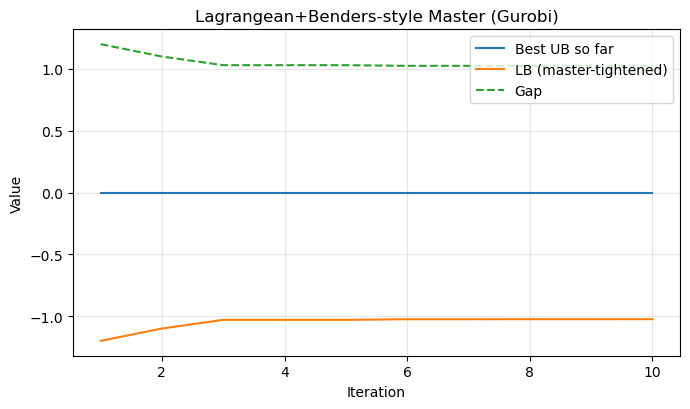

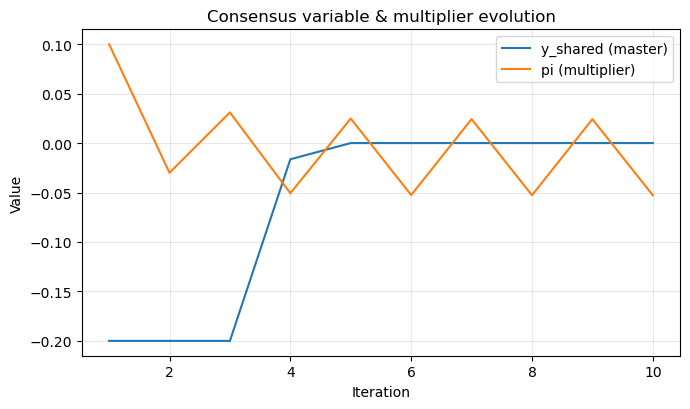

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pyomo.environ import (
    ConcreteModel, Var, Param, Constraint, Objective, Expression,
    minimize, value, SolverFactory
)

############################
# 1. 两个场景的子问题模型
############################

def build_scenario1():
    m = ConcreteModel()
    # 本场景自己的 y1
    m.y = Var(bounds=(-1, 1), initialize=0.0)
    m.x1 = Var(bounds=(0, 1), initialize=0.0)
    m.x11 = Var(bounds=(0, None), initialize=0.0)

    # 非凸关系:
    # x11^2 == y^2
    m.c1 = Constraint(expr=m.x11**2 == m.y**2)
    # x11 == (x1)^2
    m.c2 = Constraint(expr=m.x11 == m.x1**2)

    # 原始成本(不含乘子):  minimize -x1
    m.base_cost = Expression(expr= - m.x1 )

    # 拉格朗日乘子 π (mutable)
    m.pi = Param(initialize=0.0, mutable=True)

    # Lagrangean 目标: base_cost + π * y
    m.obj = Objective(expr=m.base_cost + m.pi * m.y, sense=minimize)
    return m


def build_scenario2():
    m = ConcreteModel()
    # 本场景自己的 y2
    m.y  = Var(bounds=(-0.2, 0.2), initialize=0.0)
    m.x2 = Var(bounds=(0, 1), initialize=0.0)

    # 非凸约束:
    # x2^2 >= y
    # x2^2 >= -y
    m.c1 = Constraint(expr=m.x2**2 >= m.y)
    m.c2 = Constraint(expr=m.x2**2 >= -m.y)

    # 原始成本(不含乘子): minimize x2
    m.base_cost = Expression(expr= m.x2 )

    m.pi = Param(initialize=0.0, mutable=True)

    # Lagrangean 目标: base_cost - π * y
    m.obj = Objective(expr=m.base_cost - m.pi * m.y, sense=minimize)
    return m


############################
# 2. 用 Gurobi 求解一个 Pyomo 模型
############################

def solve_model_gurobi(model):
    opt = SolverFactory("gurobi")
    # 允许非凸二次项 & 稳定数值
    opt.options["NonConvex"] = 2           # <- 关键：允许非凸 QCQP
    opt.options["NumericFocus"] = 3        # 更认真处理数值稳定
    opt.options["OutputFlag"] = 0          # 静音
    res = opt.solve(model, tee=False)
    return res


def solve_lagrangian_subproblem(model, pi_val):
    """
    给定 π (拉格朗日乘子)，解场景子问题:
    返回:
        z_star: Lagrangean 目标的最优值
        y_star: 该场景局部 y 的解
        baseval: 原始成本(不含 π*y)
    """
    model.pi.value = pi_val
    solve_model_gurobi(model)
    z_star  = value(model.obj)
    y_star  = value(model.y)
    baseval = value(model.base_cost)
    return z_star, y_star, baseval


############################
# 3. master 问题管理器
#
# master 的变量:
#   y_shared  (所有场景应该同意的共享y)
#   eta1, eta2 (每个场景的代价上界)
#
# master 的目标:
#   minimize eta1 + eta2
#
# master 的约束:
#   对场景1的所有cut: eta1 >= a + b*y_shared
#   对场景2的所有cut: eta2 >= a + b*y_shared
#
# 我们会一轮一轮往 cuts 里 push 新的 (a,b)
############################

class MasterProblem:
    def __init__(self):
        # 存的cut：列表里每个元素是 (w, a, b)
        # 表示一条约束:
        #   eta_w >= a + b * y_shared
        # w ∈ {1,2} 对应场景
        self.cuts = []

    def add_cut(self, w, a, b):
        self.cuts.append((w, a, b))

    def build_pyomo(self):
        m = ConcreteModel()

        # 全局共享y
        m.y_shared = Var(bounds=(-0.2, 0.2), initialize=0.0)

        # 每个场景的η
        m.eta1 = Var(bounds=(-1e3, 1e3), initialize=0.0)
        m.eta2 = Var(bounds=(-1e3, 1e3), initialize=0.0)

        # 动态创建cuts
        # 注意：Pyomo 需要显式命名每个约束，不然后面覆盖会警告
        m.cut_constrs = Constraint(range(len(self.cuts)))

        for i,(w,a,b) in enumerate(self.cuts):
            if w == 1:
                # eta1 >= a + b*y_shared
                m.cut_constrs[i] = ( m.eta1 >= a + b*m.y_shared )
            else:
                # eta2 >= a + b*y_shared
                m.cut_constrs[i] = ( m.eta2 >= a + b*m.y_shared )

        # 目标: min eta1 + eta2
        m.obj = Objective(expr=m.eta1 + m.eta2, sense=minimize)
        return m


def solve_master_and_get_y(master_mgr):
    """
    build master, solve with Gurobi (LP),
    返回:
        y_shared,
        LB_master (= eta1+eta2 最优值)
    """
    M = master_mgr.build_pyomo()
    solve_model_gurobi(M)
    y_shared_val = value(M.y_shared)
    LB_val       = value(M.obj)
    return y_shared_val, LB_val


############################
# 4. 给定 y_shared，计算可行上界 (UB)
#
# 这是“Benders-style recourse evaluation”：
#   - 把两个场景强行用同一个 y_shared
#   - 最优地调它们的 x 来算真实成本
############################

def compute_feasible_UB_at_y(ybar):
    # 场景1 (min -x1 s.t. x11^2=y^2, x11=x1^2, y=ybar)
    m1 = ConcreteModel()
    m1.yfix  = Param(initialize=ybar, mutable=False)
    m1.x1    = Var(bounds=(0, 1), initialize=0.0)
    m1.x11   = Var(bounds=(0, None), initialize=0.0)

    m1.c1 = Constraint(expr=m1.x11**2 == m1.yfix**2)
    m1.c2 = Constraint(expr=m1.x11 == m1.x1**2)

    m1.obj = Objective(expr= - m1.x1, sense=minimize)

    # 场景2 (min x2 s.t. x2^2>=ybar, x2^2>=-ybar)
    m2 = ConcreteModel()
    m2.yfix = Param(initialize=ybar, mutable=False)
    m2.x2   = Var(bounds=(0, 1), initialize=0.0)

    m2.c1 = Constraint(expr=m2.x2**2 >= m2.yfix)
    m2.c2 = Constraint(expr=m2.x2**2 >= -m2.yfix)

    m2.obj = Objective(expr= m2.x2, sense=minimize)

    solve_model_gurobi(m1)
    solve_model_gurobi(m2)

    z1 = value(m1.obj)
    z2 = value(m2.obj)
    return z1 + z2


############################
# 5. 外层迭代
#    - solve lagrangian subproblems
#    - add cuts to master
#    - solve master
#    - evaluate UB
#    - update multiplier pi
############################

def run_full_loop(
    max_iter=30,
    pi0=0.2,           # 非零初值，破对称
    theta0=0.5,
    alpha_cap=0.1,     # 给乘子更大步长上限
    momentum_beta=0.3,
    verbose=True
):
    scen1 = build_scenario1()
    scen2 = build_scenario2()

    master_mgr = MasterProblem()

    pi = pi0
    pi_prev = pi0
    theta = theta0

    last_gap = None
    not_improve = 0

    bestUB = np.inf

    LB_hist  = []
    UB_hist  = []
    GAP_hist = []
    y_hist   = []
    pi_hist  = []

    for k in range(1, max_iter+1):

        # --- (1) solve Lagrangean subproblems with current pi
        z1_star, y1_star, base1 = solve_lagrangian_subproblem(scen1, pi)
        z2_star, y2_star, base2 = solve_lagrangian_subproblem(scen2, pi)

        # Lagrangean下界 (未强化)
        LB_lag = z1_star + z2_star

        # --- (2) add Lagrangean cuts into master
        # 场景1 cut: eta1 >= z1_star - pi * y_shared
        master_mgr.add_cut(w=1, a=z1_star, b= -pi)
        # 场景2 cut: eta2 >= z2_star + pi * y_shared
        master_mgr.add_cut(w=2, a=z2_star, b= +pi)

        # --- (3) solve master to get y_shared and tightened LB
        y_shared, LB_master = solve_master_and_get_y(master_mgr)

        LB_effective = max(LB_lag, LB_master)

        # --- (4) evaluate feasible UB at that shared y
        UB_val = compute_feasible_UB_at_y(y_shared)
        bestUB = min(bestUB, UB_val)

        gap_now = bestUB - LB_effective

        # --- (5) multiplier update (subgradient on y1=y2)
        g = y1_star - y2_star
        denom = g*g + 1e-12
        alpha = theta * max(gap_now,0.0) / denom
        if alpha > alpha_cap:
            alpha = alpha_cap
        step = alpha * g + momentum_beta * (pi - pi_prev if k>1 else 0.0)
        

        pi_prev = pi
        pi = pi + step
        # 防炸: clip一下
        if pi > 5.0:  pi = 5.0
        if pi < -5.0: pi = -5.0

        # 步长自适应 (类似你之前那套)
        if last_gap is not None:
            if gap_now > last_gap - 1e-4:
                not_improve += 1
            else:
                not_improve = 0
            if not_improve >= 3:
                theta *= 0.5
                not_improve = 0
        last_gap = gap_now

        # --- log
        LB_hist.append(LB_effective)
        UB_hist.append(bestUB)
        GAP_hist.append(gap_now)
        y_hist.append(y_shared)
        pi_hist.append(pi)

        if verbose:
            print(
                f"[iter {k:02d}] "
                f"y1={y1_star:+.6f}, y2={y2_star:+.6f}, y_shared={y_shared:+.6f} | "
                f"LB={LB_effective:+.6e} | UB={bestUB:+.6e} | gap={gap_now:.3e} | "
                f"pi={pi:+.6e}, alpha={alpha:.3e}, theta={theta:.3f}"
            )

    return {
        "LB": LB_hist,
        "UB": UB_hist,
        "gap": GAP_hist,
        "y_shared": y_hist,
        "pi": pi_hist,
    }


############################
# 6. 主入口：跑循环 + 画图
############################

if __name__ == "__main__":
    hist = run_full_loop(
        max_iter=10,
        pi0=0.2,         # 用0.2而不是0，打破对称
        theta0=0.5,
        alpha_cap=0.1,
        momentum_beta=0.3,
        verbose=True
    )

    it = np.arange(1, len(hist["LB"])+1)

    plt.figure(figsize=(7,4.2))
    plt.plot(it, hist["UB"], label="Best UB so far")
    plt.plot(it, hist["LB"], label="LB (master-tightened)")
    plt.plot(it, hist["gap"], "--", label="Gap")
    plt.xlabel("Iteration")
    plt.ylabel("Value")
    plt.title("Lagrangean+Benders-style Master (Gurobi)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7,4.2))
    plt.plot(it, hist["y_shared"], label="y_shared (master)")
    plt.plot(it, hist["pi"], label="pi (multiplier)")
    plt.xlabel("Iteration")
    plt.ylabel("Value")
    plt.title("Consensus variable & multiplier evolution")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


model.name="unknown";
    - termination condition: maxIterations
    - message from solver: Ipopt 3.14.19\x3a Maximum Number of Iterations
      Exceeded.
iter=  1 | y1=+0.000000, y2=-0.000000, s=-0.000000 | UB=-7.587776e-05 | resid=4.969e-25
'pyomo.core.base.objective.ScalarObjective'>) on block unknown with a new
Component (type=<class 'pyomo.core.base.objective.AbstractScalarObjective'>).
This is usually indicative of a modelling error. To avoid this warning, use
block.del_component() and block.add_component().
'pyomo.core.base.objective.ScalarObjective'>) on block unknown with a new
Component (type=<class 'pyomo.core.base.objective.AbstractScalarObjective'>).
This is usually indicative of a modelling error. To avoid this warning, use
block.del_component() and block.add_component().
iter=  2 | y1=+0.085499, y2=+0.000000, s=+0.051299 | UB=-2.198479e-08 | resid=8.550e-02
'pyomo.core.base.objective.ScalarObjective'>) on block unknown with a new
Component (type=<class 'pyomo.core.base.o

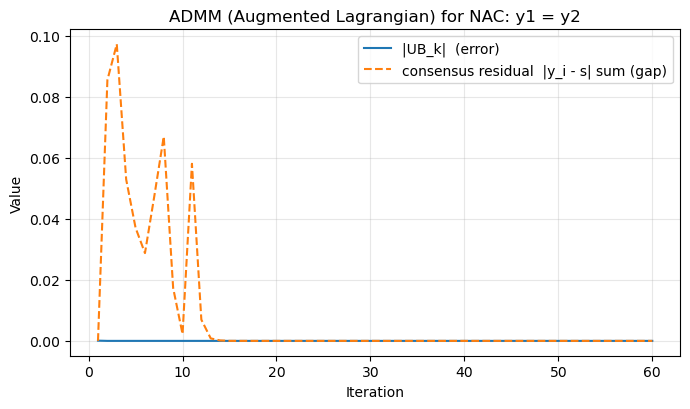

In [6]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
from pyomo.environ import (ConcreteModel, Var, Constraint, Expression, Objective,
                           Param, minimize, value, SolverFactory)

# ===== 真实值函数（可不用） =====
def v_1(y):  return -np.sqrt(abs(y))
def v_2(y):  return  np.sqrt(abs(y))

# ===== 变量范围 =====
ylb, yub = -0.2, 0.2

# ===== 构建两个场景模型，加入 ADMM 所需的 (s,u,rho) 可变参数 =====
def build_scene1():
    m = ConcreteModel()
    m.y  = Var(bounds=(ylb, yub), initialize=0.0)
    m.x1 = Var(bounds=(0, 1), initialize=0.0)
    m.x11= Var(bounds=(0, None), initialize=0.0)
    m.c1 = Constraint(expr=m.x11**2 == m.y**2)
    m.c2 = Constraint(expr=m.x11 == (m.x1)**2)
    m.base = Expression(expr=-m.x1)              # 原始目标
    # ADMM 参数
    m.s   = Param(initialize=0.0, mutable=True)
    m.u   = Param(initialize=0.0, mutable=True)
    m.rho = Param(initialize=10.0, mutable=True)
    m.obj = Objective(expr=m.base + 0.5*m.rho*(m.y - m.s + m.u)**2, sense=minimize)
    return m

def build_scene2():
    m = ConcreteModel()
    m.y  = Var(bounds=(ylb, yub), initialize=0.0)
    m.x2 = Var(bounds=(0, 1), initialize=0.0)
    m.c1 = Constraint(expr=m.x2**2 >=  m.y)
    m.c2 = Constraint(expr=m.x2**2 >= -m.y)
    m.base = Expression(expr= m.x2)              # 原始目标
    m.s   = Param(initialize=0.0, mutable=True)
    m.u   = Param(initialize=0.0, mutable=True)
    m.rho = Param(initialize=10.0, mutable=True)
    m.obj = Objective(expr=m.base + 0.5*m.rho*(m.y - m.s + m.u)**2, sense=minimize)
    return m

SOLVER = "ipopt"
SOLVER_OPTS = {"tol": 1e-9, "print_level": 0, "max_iter": 200}

def solve_model(model):
    opt = SolverFactory(SOLVER)
    for k,v in SOLVER_OPTS.items():
        try: opt.options[k]=v
        except: pass
    return opt.solve(model, tee=False)

# ===== 计算可行上界：把 y 固定为共识 s，分别用原始目标求值并相加 =====
def feasible_UB_at_s(m1, m2, s):
    # 场景1
    if hasattr(m1, "fixy"): m1.del_component(m1.fixy)
    m1.fixy = Constraint(expr=m1.y == s)
    # 暂时替换目标为原始目标
    m1.obj.deactivate()
    m1.obj_feas = Objective(expr=m1.base, sense=minimize)
    solve_model(m1)
    z1 = value(m1.base)
    m1.obj_feas.deactivate(); m1.obj.activate()
    m1.fixy.deactivate()
    # 场景2
    if hasattr(m2, "fixy"): m2.del_component(m2.fixy)
    m2.fixy = Constraint(expr=m2.y == s)
    m2.obj.deactivate()
    m2.obj_feas = Objective(expr=m2.base, sense=minimize)
    solve_model(m2)
    z2 = value(m2.base)
    m2.obj_feas.deactivate(); m2.obj.activate()
    m2.fixy.deactivate()
    return z1 + z2

# ===== ADMM 主循环 =====
def run_admm(max_iter=60, rho=20.0, relax=1.0, verbose=True):
    m1, m2 = build_scene1(), build_scene2()
    # 初始化
    s  = 0.0                  # 共识变量
    u1 = 0.0                  # 缩放对偶 for scene1
    u2 = 0.0                  # 缩放对偶 for scene2
    # 日志
    ub_hist, err_hist, res_hist = [], [], []

    for k in range(1, max_iter+1):
        # 参数下发
        m1.s.value = s;  m1.u.value = u1;  m1.rho.value = rho
        m2.s.value = s;  m2.u.value = u2;  m2.rho.value = rho

        # 1) 场景子问题（并行独立）
        solve_model(m1); y1 = value(m1.y)
        solve_model(m2); y2 = value(m2.y)

        # 2) 共识更新（可加过松弛）
        s_old = s
        s_new = 0.5*((y1+u1) + (y2+u2))
        s_new = min(max(s_new, ylb), yub)    # 投影到区间
        s = (1-relax)*s + relax*s_new        # 过松弛

        # 3) 对偶更新
        u1 = u1 + (y1 - s)
        u2 = u2 + (y2 - s)

        # 4) 可行上界 & 指标
        UB = feasible_UB_at_s(m1, m2, s)     # 原问题可行值
        ub_hist.append(UB)
        err_hist.append(abs(UB))             # 最优值=0
        res = abs(y1 - s) + abs(y2 - s)      # 共识残差（橙线）
        res_hist.append(res)

        if verbose:
            print(f"iter={k:3d} | y1={y1:+.6f}, y2={y2:+.6f}, s={s:+.6f} | "
                  f"UB={UB:+.6e} | resid={res:.3e}")

        # 简单自适应：残差若停滞，提高 rho
        if k % 10 == 0 and np.median(res_hist[-10:]) > 0.1*np.median(res_hist[:10] or [1.0]):
            rho *= 1.5

    return ub_hist, err_hist, res_hist

if __name__ == "__main__":
    max_iter = 60
    # 经验上：rho=10~50，relax=1.2 左右很稳
    ub_hist, err_hist, res_hist = run_admm(max_iter=max_iter, rho=20.0, relax=1.2, verbose=True)

    it = np.arange(1, max_iter+1)
    plt.figure(figsize=(7,4.2))
    plt.plot(it, err_hist, label="|UB_k|  (error)")
    plt.plot(it, res_hist, "--", label="consensus residual  |y_i - s| sum (gap)")
    plt.xlabel("Iteration"); plt.ylabel("Value")
    plt.title("ADMM (Augmented Lagrangian) for NAC: y1 = y2")
    plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()


# P1

In [2]:
from pyomo.environ import *
import numpy as np
import matplotlib.pyplot as plt
import bisect
from pyomo.opt import SolverStatus, TerminationCondition

In [3]:
from dataclasses import dataclass, field
from typing import Callable, List, Dict, Tuple
import math
from pyomo.opt import SolverStatus, TerminationCondition
from typing import List, Dict

Lagrangian part

In [4]:
# ========== Solve Lagrangian relaxation once ==========
def solve_lagrangian_once(model_list: List[ConcreteModel], lambdas: List[float]):
    solver = SolverFactory("gurobi")
    xs, objs = [], []
    N = len(model_list)
    for n, m in enumerate(model_list):
        if hasattr(m, 'obj'):
            m.del_component(m.obj)
        lag_term = (lambdas[n+1]-lambdas[n]) * m.y
        m.obj = Objective(expr = m.obj_expr + lag_term, sense=minimize)
        solver.solve(m, tee=False)
        xs.append(value(m.y))
        objs.append(value(m.obj))
    return xs, objs, sum(objs)

# ========== subgradient lambda update ==========
def subgradient_update(
    lambdas: list[float],
    xs: list[float],                       
    zUB: float,
    zLB: float,
    alpha_fac: float = 0.5           
) -> list[float]:
    """
    g_n = x^n - x^{n+1},  n=1,...,N-1
    t = α * (zUB - zLB) / ||g||^2
    """
    N = len(xs)
    g = [xs[n] - xs[n+1] for n in range(N-1)]
    g2 = sum(gi*gi for gi in g)
    if g2 <= 1e-16:
        return lambdas[:]
    t = alpha_fac * max(0.0, zUB - zLB) / g2
    new_lambdas = [0]
    for i, lam in enumerate(lambdas):
        if 1<=i<=(N-1):
            new_lambdas.append(lam + t * g[i-1]) 
    new_lambdas.append(0)
    return new_lambdas

# ========== main loop ==========
def lagrangian_loop(model_list: List[ConcreteModel],
                    max_iter: int = 20,
                    zUB: float = 1e9,
                    t: float = 0.5,
                    lam0: List[float] = None):
    N = len(model_list)
    lambdas = lam0 if lam0 is not None else [0.0]*(N+1)
    history = []
    for k in range(max_iter):
        xs, objs, zLB = solve_lagrangian_once(model_list, lambdas)
        history.append((k, zLB, xs, lambdas[:]))
        print(f"iter {k:02d}: zLB={zLB:.6f}, xs={['%.4f'%x for x in xs]}, λ={['%.3f'%l for l in lambdas]}")
        print('lower bound is ',sum(objs))
        lambdas = subgradient_update(lambdas, xs, zUB, zLB)
    return history

nc_underest part